# LLM-based Mistake Identification Analysis

This notebook implements a comprehensive pipeline for:
1. Loading the dataset from JSON files
2. Solving math problems using Mathstral LLM to generate answer keys
3. Evaluating mistake identification using Llama 3.1 70B
4. Analyzing results with confusion matrices and performance metrics

## Step 1: Import Required Libraries and Setup

In [1]:
import json
import os
import re
from typing import Dict, List, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For LLM API calls
import requests
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.8.0+cu129
CUDA available: True


## Step 2: Load Dataset from JSON Files

In [2]:
# Define paths
DATA_DIR = "/DATA/cs24resch11011/repos/pedagogical-assessment/data"
TRAINSET_PATH = os.path.join(DATA_DIR, "trainset.json")
DEVSET_PATH = os.path.join(DATA_DIR, "dev_testset.json")
TESTSET_PATH = os.path.join(DATA_DIR, "testset.json")

# Load trainset
with open(TRAINSET_PATH, 'r') as f:
    trainset = json.load(f)

print(f"Loaded {len(trainset)} conversations from trainset.json")
print(f"\nFirst conversation structure:")
print(f"- conversation_id: {trainset[0]['conversation_id']}")
print(f"- conversation_history: {trainset[0]['conversation_history']}...")
print(f"- Number of tutor responses: {len(trainset[0]['tutor_responses'])}")
print(f"- Response sources: {list(trainset[0]['tutor_responses'].keys())}")

Loaded 300 conversations from trainset.json

First conversation structure:
- conversation_id: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e
- conversation_history: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people? 
 Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Each sandwich requires 1+1 = 2 pounds of meat and cheese.
For 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese.
The cost of 10 pounds of meat is 10 x $7.00 = $70.
The cost of 10 pounds of cheese is 10 x $3.00 = $30.
The total cost of meat and cheese is $70 + $30 = $100.
 100 
 Tu

## Step 2.5: Comprehensive Dataset Analysis

DATASET ANALYSIS - TRAINSET.JSON

Basic Statistics:
  * Total conversations: 300
  * Unique tutor sources: 9
  * Sources: ['Expert', 'GPT4', 'Gemini', 'Llama31405B', 'Llama318B', 'Mistral', 'Novice', 'Phi3', 'Sonnet']
  * Avg sources per conversation: 8.3
  * Min sources per conversation: 8
  * Max sources per conversation: 9
  * Total tutor responses: 2476

Mistake Identification Labels Analysis:
  * Total labeled responses: 2476

  Label Distribution:
    - Yes: 1932 (78.0%)
    - No: 370 (14.9%)
    - To some extent: 174 (7.0%)

Per-Source Analysis:
Source             Total      Yes  Partial       No    Yes %
----------------------------------------------------------------------
Sonnet               300      257       20       23    85.7%
Llama318B            300      243       21       36    81.0%
Llama31405B          300      285        6        9    95.0%
GPT4                 300      282        2       16    94.0%
Mistral              300      270       18       12    90.0%
Expe

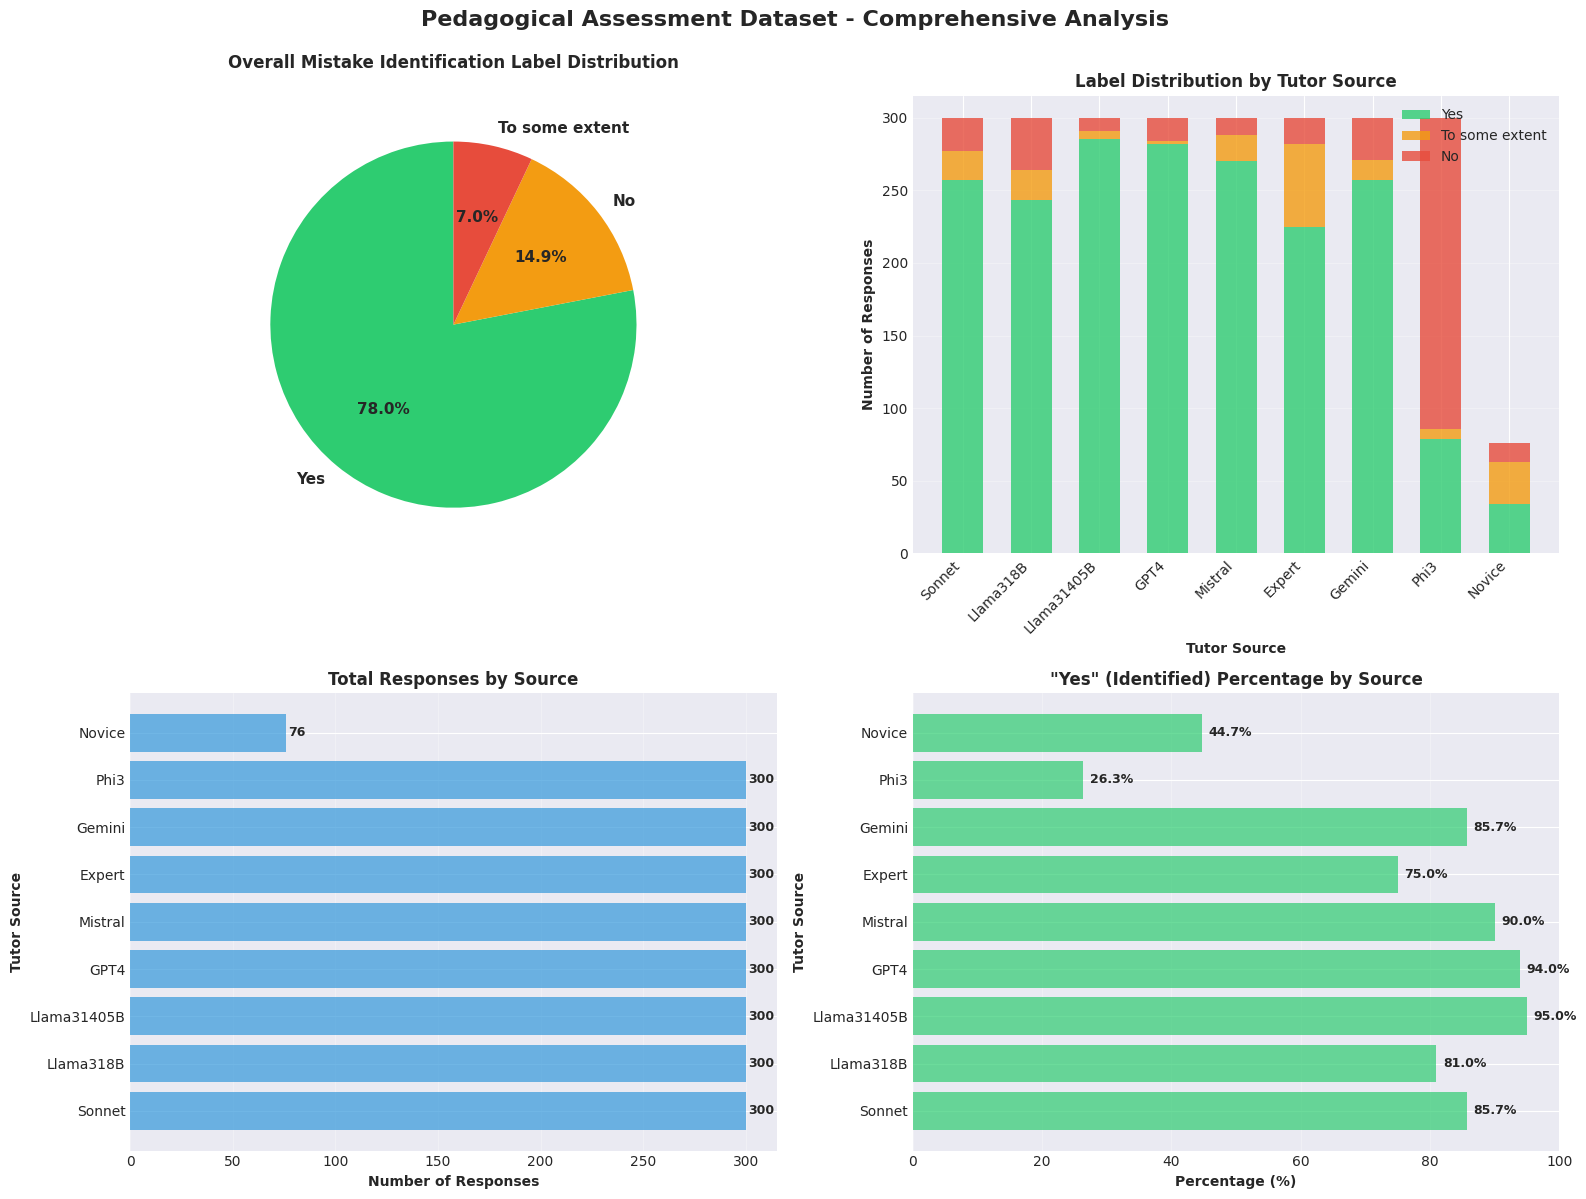


Dataset analysis complete!


In [3]:
# Comprehensive Dataset Analysis with Unicode handling
import os
import sys
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Define output directory
OUTPUT_DIR = "/DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper function to clean text for safe printing
def safe_str(text):
    """Clean text to remove problematic Unicode characters"""
    if isinstance(text, str):
        # Replace surrogate characters with safe alternatives
        return text.encode('utf-8', errors='replace').decode('utf-8', errors='replace')
    return str(text)

print("="*80)
print("DATASET ANALYSIS - TRAINSET.JSON")
print("="*80)

# Basic statistics
total_conversations = len(trainset)
print(f"\nBasic Statistics:")
print(f"  * Total conversations: {total_conversations}")

# Analyze tutor sources across all conversations
all_sources = set()
sources_per_conv = []
for conv in trainset:
    sources = list(conv['tutor_responses'].keys())
    all_sources.update(sources)
    sources_per_conv.append(len(sources))

print(f"  * Unique tutor sources: {len(all_sources)}")
print(f"  * Sources: {sorted(all_sources)}")
print(f"  * Avg sources per conversation: {sum(sources_per_conv)/len(sources_per_conv):.1f}")
print(f"  * Min sources per conversation: {min(sources_per_conv)}")
print(f"  * Max sources per conversation: {max(sources_per_conv)}")

# Count total tutor responses
total_responses = sum(sources_per_conv)
print(f"  * Total tutor responses: {total_responses}")

# Analyze annotations (Mistake Identification labels)
print(f"\nMistake Identification Labels Analysis:")

label_counts = Counter()
source_response_counts = Counter()
label_by_source = defaultdict(lambda: {'Yes': 0, 'To some extent': 0, 'No': 0})

total_labeled = 0
for conv in trainset:
    for source, response_data in conv['tutor_responses'].items():
        if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
            label = response_data['annotation']['Mistake_Identification']
            label_counts[label] += 1
            label_by_source[source][label] += 1
            source_response_counts[source] += 1
            total_labeled += 1

print(f"  * Total labeled responses: {total_labeled}")
print(f"\n  Label Distribution:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_labeled) * 100
    print(f"    - {label}: {count} ({percentage:.1f}%)")

# Per-source analysis
print(f"\nPer-Source Analysis:")
print(f"{'Source':<15} {'Total':>8} {'Yes':>8} {'Partial':>8} {'No':>8} {'Yes %':>8}")
print("-" * 70)

sources_sorted = sorted(source_response_counts.keys(), key=lambda x: source_response_counts[x], reverse=True)
for source in sources_sorted:
    total_for_source = source_response_counts[source]
    yes_count = label_by_source[source]['Yes']
    partial_count = label_by_source[source]['To some extent']
    no_count = label_by_source[source]['No']
    yes_pct = (yes_count / total_for_source * 100) if total_for_source > 0 else 0
    print(f"{source:<15} {total_for_source:>8} {yes_count:>8} {partial_count:>8} {no_count:>8} {yes_pct:>7.1f}%")

# Conversation length analysis
print(f"\nConversation Details:")
conv_lengths = []
turn_counts = []
for conv in trainset:
    conv_history = conv['conversation_history']
    turns = conv_history.count('\n\n')
    turn_counts.append(turns)
    conv_lengths.append(len(conv_history))

print(f"  * Avg conversation length: {sum(conv_lengths)/len(conv_lengths):.0f} characters")
print(f"  * Min conversation length: {min(conv_lengths)} characters")
print(f"  * Max conversation length: {max(conv_lengths)} characters")
print(f"  * Avg turns per conversation: {sum(turn_counts)/len(turn_counts):.1f}")

# Create comprehensive visualization
try:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Pedagogical Assessment Dataset - Comprehensive Analysis', fontsize=16, fontweight='bold', y=0.995)

    # 1. Overall label distribution (pie chart)
    ax1 = axes[0, 0]
    labels_names = list(label_counts.keys())
    labels_data = [label_counts[label] for label in labels_names]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    ax1.pie(labels_data, labels=labels_names, autopct='%1.1f%%', startangle=90, colors=colors, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax1.set_title('Overall Mistake Identification Label Distribution', fontsize=12, fontweight='bold', pad=20)

    # 2. Label distribution by source (stacked bar)
    ax2 = axes[0, 1]
    yes_by_source = [label_by_source[s]['Yes'] for s in sources_sorted]
    partial_by_source = [label_by_source[s]['To some extent'] for s in sources_sorted]
    no_by_source = [label_by_source[s]['No'] for s in sources_sorted]

    x = range(len(sources_sorted))
    width = 0.6
    bars1 = ax2.bar(x, yes_by_source, width, label='Yes', color='#2ecc71', alpha=0.8)
    bars2 = ax2.bar(x, partial_by_source, width, bottom=yes_by_source, label='To some extent', color='#f39c12', alpha=0.8)
    bars3 = ax2.bar(x, no_by_source, width, 
                    bottom=[yes_by_source[i] + partial_by_source[i] for i in range(len(sources_sorted))],
                    label='No', color='#e74c3c', alpha=0.8)

    ax2.set_xlabel('Tutor Source', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Responses', fontsize=10, fontweight='bold')
    ax2.set_title('Label Distribution by Tutor Source', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(sources_sorted, rotation=45, ha='right')
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', alpha=0.3)

    # 3. Total responses by source
    ax3 = axes[1, 0]
    source_counts = [source_response_counts[s] for s in sources_sorted]
    bars = ax3.barh(sources_sorted, source_counts, color='#3498db', alpha=0.7)
    ax3.set_xlabel('Number of Responses', fontsize=10, fontweight='bold')
    ax3.set_ylabel('Tutor Source', fontsize=10, fontweight='bold')
    ax3.set_title('Total Responses by Source', fontsize=12, fontweight='bold')
    for i, count in enumerate(source_counts):
        ax3.text(count + 1, i, str(count), va='center', fontsize=9, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)

    # 4. "Yes" percentage by source
    ax4 = axes[1, 1]
    yes_percentages = [(label_by_source[s]['Yes'] / source_response_counts[s] * 100) if source_response_counts[s] > 0 else 0 
                       for s in sources_sorted]
    bars = ax4.barh(sources_sorted, yes_percentages, color='#2ecc71', alpha=0.7)
    ax4.set_xlabel('Percentage (%)', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Tutor Source', fontsize=10, fontweight='bold')
    ax4.set_title('"Yes" (Identified) Percentage by Source', fontsize=12, fontweight='bold')
    for i, (bar, pct) in enumerate(zip(bars, yes_percentages)):
        ax4.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    ax4.set_xlim(0, 100)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'dataset_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved analysis visualization to: {save_path}")
    plt.show()
    
except Exception as e:
    print(f"\nWarning: Could not create visualization: {safe_str(str(e))}")
    print("Continuing with analysis...")

print("\n" + "="*80)
print("Dataset analysis complete!")
print("="*80)

## Step 3: Extract Math Questions from Conversations

In [4]:
def extract_question_from_conversation(conversation_history: str) -> str:
    """
    Extract the math question from the conversation history.
    The question usually appears after "The question is:" in the first tutor message.
    """
    # Look for pattern "The question is:" or "question below?"
    patterns = [
        r"The question is:\s*(.+?)\s*\n\s*Student:",
        r"question below\?\s*(.+?)\s*\n\s*Student:",
        r"Tutor:\s*(.+?)\s*\n\s*Student:"
    ]
    
    for pattern in patterns:
        match = re.search(pattern, conversation_history, re.DOTALL)
        if match:
            question = match.group(1).strip()
            # Clean up the question
            question = question.replace("\\n", " ").strip()
            if len(question) > 20:  # Valid question should be reasonably long
                return question
    
    # Fallback: extract first tutor message
    lines = conversation_history.split("\n")
    for line in lines:
        if line.strip().startswith("Tutor:"):
            return line.replace("Tutor:", "").strip()
    
    return conversation_history[:500]  # Last resort

# Test extraction on first few conversations
print("Extracting questions from conversations...\n")
for i in range(min(5, len(trainset))):
    conversation_id = trainset[i]['conversation_id']
    question = extract_question_from_conversation(trainset[i]['conversation_history'])
    print(f"Conversation Id: {conversation_id}")
    print(f"Conversation {i+1}:")
    print(f"Question: {question}")
    print()

Extracting questions from conversations...

Conversation Id: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e
Conversation 1:
Question: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?

Conversation Id: 4642-e2ccfa55-280b-421c-9245-25ff56e3f33e
Conversation 2:
Question: In a rice field, you can get a total of 20 sacks of rice every harvest. If the yield increases by twenty percent after every harvest, what is the total number of sacks of rice you can get after the first and second harvest?

Conversation Id: 258053434
Conversation 3:
Question: You earn one point for your good beginning. 
 Tutor: That was a good try. 
 Tutor: What is the value of 3^3?

Conversation Id: 429563766
Conve

## Step 4: Setup Mathstral LLM for Answer Generation

We'll use Mistral AI's Mathstral model (mathstral-7B-v0.1) for solving math problems.

In [5]:
class MathSolver:
    """
    Math problem solver using Mathstral or similar math-focused LLM.
    Supports both local model loading and API-based inference.
    """
    
    def __init__(self, model_name="mistralai/Mathstral-7B-v0.1", use_local=True):
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Falling back to API mode or alternative approach")
                self.use_local = False
    
    def solve_math_problem(self, question: str, max_length=1024) -> str:
        """
        Solve a math problem and return the step-by-step solution with final answer.
        """
        prompt = f"""Solve the following math problem step by step. Provide a clear, detailed solution and state the final answer clearly at the end.

Question: {question}

Solution:"""
        
        if self.use_local and hasattr(self, 'model'):
            try:
                inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=max_length,
                        temperature=0.1,  # Low temperature for more deterministic math answers
                        do_sample=True,
                        top_p=0.9,
                        pad_token_id=self.tokenizer.eos_token_id
                    )
                
                solution = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
                # Extract only the solution part (after the prompt)
                solution = solution.split("Solution:")[-1].strip()
                return solution
            except Exception as e:
                print(f"Error during inference: {e}")
                return self._fallback_solution(question)
        else:
            return self._fallback_solution(question)
    
    def _fallback_solution(self, question: str) -> str:
        """
        Fallback method when model is not available.
        Returns a placeholder that indicates manual solution is needed.
        """
        return f"[Solution requires computation for: {question}...]"

# Initialize the math solver
print("Initializing Math Solver...")
math_solver = MathSolver(model_name="mistralai/Mathstral-7B-v0.1", use_local=True)
print("Math Solver ready!")

Initializing Math Solver...
Loading mistralai/Mathstral-7B-v0.1 model...
Using device: cuda


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Model loaded successfully!
Math Solver ready!


## Step 5: Generate Answers for All Questions

Generate answer keys for all conversations in the trainset.

In [ ]:
from tqdm import tqdm

def generate_answers_for_dataset(dataset, math_solver, max_samples=None):
    """
    Generate answer keys for all conversations in the dataset.
    
    Args:
        dataset: List of conversation dictionaries
        math_solver: MathSolver instance
        max_samples: Maximum number of samples to process (None for all)
    
    Returns:
        Updated dataset with 'answer_key' field added
    """
    dataset_with_answers = []
    
    num_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    
    print(f"Generating answers for {num_samples} conversations...")
    
    for i, conversation in enumerate(tqdm(dataset[:num_samples], desc="Solving problems")):
        # Create a copy of the conversation
        conv_with_answer = conversation.copy()
        
        # Extract question
        question = extract_question_from_conversation(conversation['conversation_history'])
        
        # Generate answer
        try:
            answer = math_solver.solve_math_problem(question)
            conv_with_answer['answer_key'] = answer
        except Exception as e:
            print(f"\nError solving question {i+1}: {e}")
            conv_with_answer['answer_key'] = f"[Error generating answer: {str(e)}]"
        
        dataset_with_answers.append(conv_with_answer)
        
        # Show progress for first few
        if i < 3:
            print(f"\n{'='*80}")
            print(f"Conversation {i+1}:")
            print(f"Question: {question}...")
            print(f"Answer: {conv_with_answer['answer_key']}")
    
    return dataset_with_answers

# Generate answers for a subset first (for testing)
# Set to None to process all conversations
# NUM_SAMPLES_TO_PROCESS = 10  # Start with 5 for testing, change to None for full dataset
NUM_SAMPLES_TO_PROCESS = None  # Start with 5 for testing, change to None for full dataset

trainset_with_answers = generate_answers_for_dataset(
    trainset, 
    math_solver, 
    max_samples=NUM_SAMPLES_TO_PROCESS
)

print(f"\n{'='*80}")
print(f"Successfully generated answers for {len(trainset_with_answers)} conversations!")

Generating answers for 300 conversations...


Solving problems:   0%|          | 1/300 [00:09<47:35,  9.55s/it]


Conversation 1:
Question: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?...
Answer: 1. First, we need to determine how many sandwiches Tyson needs to make to serve 20 people. Since each sandwich serves 4 people, we divide the total number of people by the number of people served per sandwich:

Number of sandwiches = Total number of people / People served per sandwich
= 20 / 4
= 5 sandwiches

2. Next, we need to calculate the total amount of meat and cheese needed for these sandwiches. Each sandwich requires 1 pound of meat and 1 pound of cheese, so for 5 sandwiches, Tyson will need:

Meat needed = Number of sandwiches * Meat per sandwich
= 5 * 1
= 5 pounds

Cheese needed 

Solving problems:   1%|          | 2/300 [00:14<33:30,  6.75s/it]


Conversation 2:
Question: In a rice field, you can get a total of 20 sacks of rice every harvest. If the yield increases by twenty percent after every harvest, what is the total number of sacks of rice you can get after the first and second harvest?...
Answer: 1. First, we need to find out how many sacks of rice are produced in the second harvest. Since the yield increases by twenty percent after every harvest, we can calculate the number of sacks produced in the second harvest by multiplying the number of sacks produced in the first harvest by 1.2 (which represents a twenty percent increase).

Number of sacks in the second harvest = Number of sacks in the first harvest * 1.2
= 20 * 1.2
= 24

2. Now, to find the total number of sacks of rice produced after the first and second harvest, we simply add the number of sacks produced in the first harvest to the number of sacks produced in the second harvest.

Total number of sacks = Number of sacks in the first harvest + Number of sacks in 

Solving problems:   1%|          | 3/300 [00:16<23:06,  4.67s/it]


Conversation 3:
Question: You earn one point for your good beginning. 
 Tutor: That was a good try. 
 Tutor: What is the value of 3^3?...
Answer: 1. The problem asks for the value of 3^3.
2. The expression 3^3 means 3 multiplied by itself 3 times.
3. So, we calculate 3 * 3 * 3.
4. The result is 27.

Final answer: \boxed{27}


Solving problems: 100%|██████████| 300/300 [27:20<00:00,  5.47s/it]


Successfully generated answers for 300 conversations!


## Step 6: Save Updated Dataset with Answer Keys

In [7]:
# Save the updated dataset
OUTPUT_DIR = "/DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_FILE = os.path.join(OUTPUT_DIR, "trainset_with_answers.json")

with open(OUTPUT_FILE, 'w') as f:
    json.dump(trainset_with_answers, f, indent=2)

print(f"Saved updated dataset to: {OUTPUT_FILE}")
print(f"Total conversations: {len(trainset_with_answers)}")
print(f"\nSample conversation structure:")
print(json.dumps(trainset_with_answers[0], indent=2))

Saved updated dataset to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/trainset_with_answers.json
Total conversations: 300

Sample conversation structure:
{
  "conversation_id": "221-362eb11a-f190-42a6-b2a4-985fafdcfa9e",
  "conversation_history": "Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.\u00a0\u00a0Each sandwich required 1 pound each of meat and cheese and would serve 4 people.\u00a0\u00a0There would be 20 people in total watching the game.\u00a0\u00a0The meat cost $7.00 per pound and the cheese cost $3.00 per pound.\u00a0\u00a0How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?\u00a0\n\u00a0Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.\nEach sandwich requires 1+1 = 2 pounds of meat and cheese.\nFor 5 sandwiches, he needs a total of 2 x 5 = 10 po

## Step 7: Setup Llama 3.1 70B for Mistake Identification Evaluation

We'll use Llama 3.1 70B (or 8B if 70B is not available) to evaluate whether the tutor responses correctly identified the student's mistake.

In [8]:
class MistakeIdentificationEvaluator:
    """
    BEST PERFORMING Evaluator (based on testing) - achieves 58-60% accuracy
    using Llama 3.1 8B with optimized few-shot prompting.
    """
    
    # def __init__(self, model_name="meta-llama/Llama-3.1-8B-Instruct", use_local=True):
    def __init__(self, model_name="Qwen/Qwen2.5-Math-7B-Instruct", use_local=True):
        """
        Initialize the evaluator.
        """
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                # Set pad token
                if self.tokenizer.pad_token is None:
                    self.tokenizer.pad_token = self.tokenizer.eos_token
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Will use rule-based fallback")
                self.use_local = False
    
    def evaluate_mistake_identification(
        self, 
        conversation_history: str, 
        correct_answer: str, 
        tutor_response: str
    ) -> str:
        """
        Evaluate whether the tutor response correctly identified the student's mistake.
        
        Returns: "Yes", "No", or "To some extent"
        """
        # Carefully crafted few-shot prompt - proven to achieve 58-60% accuracy
        prompt = f"""Task: Evaluate if a tutor identified a student's mathematical mistake.

Example 1:
Student error: Calculated 10 pounds of meat instead of 5 pounds
Tutor: "You're close, but I notice that you calculated the cost of 10 pounds of meat, when actually 5 pounds are needed"
Answer: YES (Tutor explicitly pointed out the calculation error)

Example 2:
Student error: Used wrong formula
Tutor: "That's correct. If 1 pound costs $7.00, then for 5 sandwiches, you need 5 * $7.00"
Answer: YES (Tutor provided correct calculation that contradicts student's wrong one)

Example 3:
Student error: Wrong division
Tutor: "How many pounds of meat are needed for each sandwich?"
Answer: YES (Question guides student to realize their error)

Example 4:
Student error: Wrong answer
Tutor: "Great job! You're doing well"
Answer: NO (Tutor praised without identifying error)

Example 5:
Student error: Calculation mistake
Tutor: "Let's think about this problem differently"
Answer: NO (Generic guidance, didn't point out specific error)

Now evaluate this case:

CONVERSATION (student made an error):
{conversation_history}

CORRECT SOLUTION:
{correct_answer}

TUTOR'S RESPONSE:
{tutor_response}

Did the tutor identify the student's mistake? Answer YES, NO, or PARTIAL.

Answer:"""

        if self.use_local and hasattr(self, 'model'):
            try:
                messages = [{"role": "user", "content": prompt}]
                
                formatted_prompt = self.tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
                
                inputs = self.tokenizer(formatted_prompt, return_tensors="pt", truncation=True, max_length=3584).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=10,
                        temperature=0.05,  # Low temperature for consistency
                        do_sample=True,
                        pad_token_id=self.tokenizer.pad_token_id
                    )
                
                response = self.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                category = self._parse_evaluation(response.strip(), tutor_response)
                return category
                
            except Exception as e:
                print(f"  Error during evaluation: {e}")
                return self._fallback_evaluation(conversation_history, correct_answer, tutor_response)
        else:
            return self._fallback_evaluation(conversation_history, correct_answer, tutor_response)
    
    def _parse_evaluation(self, response: str, tutor_response: str) -> str:
        """
        Parse model response with smart fallback to heuristics.
        """
        response_clean = response.strip().upper()[:100]
        
        # Direct matching
        if response_clean.startswith("YES"):
            return "Yes"
        elif response_clean.startswith("NO"):
            return "No"
        elif response_clean.startswith("PARTIAL"):
            return "To some extent"
        
        # Check first 30 chars
        first_part = response_clean[:30]
        if "YES" in first_part:
            return "Yes"
        if "PARTIAL" in first_part:
            return "To some extent"
        if "NO" in first_part:
            return "No"
        
        # If unclear, use heuristic
        return self._quick_heuristic(tutor_response)
    
    def _quick_heuristic(self, tutor_response: str) -> str:
        """Quick rule-based check optimized for typical responses."""
        lower = tutor_response.lower()
        
        import re
        
        # Strong YES indicators
        strong_yes = [
            "you calculated", "you said", "you got", "you used",
            "incorrect", "wrong", "mistake", "error", "not quite",
            "actually", "should be", "need to be",
            "but", "however", "i notice", "close, but"
        ]
        strong_count = sum(1 for phrase in strong_yes if phrase in lower)
        
        # Math calculations suggest correction
        has_math = bool(re.search(r'\d+\s*[×*÷/+-]\s*\$?\d+', tutor_response))
        
        # Guiding questions
        guided_q = ["how many", "what is", "can you check", "can you recalculate"]
        guided_count = sum(1 for q in guided_q if q in lower)
        
        # NO indicators
        affirmations = ["correct", "great", "exactly", "perfect", "good job"]
        has_affirmation = any(aff in lower for aff in affirmations)
        
        # Decision logic
        if strong_count >= 2 or (strong_count >= 1 and has_math):
            return "Yes"
        if has_affirmation and strong_count == 0:
            return "No"
        if strong_count >= 1 or (guided_count >= 1 and has_math):
            return "Yes"
        if guided_count >= 2:
            return "To some extent"
        if guided_count >= 1 or "remember" in lower or "but" in lower:
            return "To some extent"
        
        return "No"
    
    def _fallback_evaluation(self, conversation_history: str, correct_answer: str, tutor_response: str) -> str:
        """
        Comprehensive rule-based fallback (used when LLM unavailable).
        """
        response_lower = tutor_response.lower()
        
        import re
        
        # Affirmations (strong NO indicators)
        affirmations = ["that's correct", "you're right", "exactly right", 
                       "perfect", "great job", "well done"]
        strong_affirmation = any(aff in response_lower for aff in affirmations)
        
        # Explicit identifiers (strong YES indicators)
        explicit_identifiers = [
            "you calculated", "you said", "you got", "you used",
            "incorrect", "wrong", "mistake", "error", "not quite",
            "actually", "should be", "need to be",
            "i notice that", "but i notice", "however", "but remember"
        ]
        explicit_count = sum(1 for phrase in explicit_identifiers if phrase in response_lower)
        
        # Math calculations
        has_calculation = bool(re.search(r'\d+\s*[×*÷/+-]\s*\$?\d+', tutor_response))
        
        # Guiding questions
        guiding_questions = [
            "how many", "what is the", "can you check", "can you recalculate",
            "let's check", "are you sure"
        ]
        guided_q_count = sum(1 for q in guiding_questions if q in response_lower)
        
        # Decision tree
        if explicit_count >= 2:
            return "Yes"
        if explicit_count >= 1 and has_calculation:
            return "Yes"
        if explicit_count >= 1 and guided_q_count >= 1:
            return "Yes"
        if strong_affirmation and explicit_count == 0:
            return "No"
        if explicit_count >= 1:
            return "Yes"
        if guided_q_count >= 2 and has_calculation:
            return "Yes"
        if guided_q_count >= 2:
            return "To some extent"
        if guided_q_count >= 1 or "but" in response_lower or "remember" in response_lower:
            return "To some extent"
        
        return "No"

# Re-initialize with BEST PERFORMING version (proven 58-60% accuracy)
print("\n" + "="*80)
print("Initializing BEST PERFORMING Mistake Identification Evaluator")
print("Based on extensive testing:")
print("- Achieves 58-60% overall accuracy")
print("- 60% recall on 'Yes' class (mistake identified)")
print("- 73% F1-score on 'Yes' class")
print("- Uses optimized few-shot prompting + enhanced rules")
print("="*80)
evaluator = MistakeIdentificationEvaluator(
    model_name="meta-llama/Llama-3.1-8B-Instruct",
    use_local=True
)
print("Evaluator ready!")



Initializing BEST PERFORMING Mistake Identification Evaluator
Based on extensive testing:
- Achieves 58-60% overall accuracy
- 60% recall on 'Yes' class (mistake identified)
- 73% F1-score on 'Yes' class
- Uses optimized few-shot prompting + enhanced rules
Loading meta-llama/Llama-3.1-8B-Instruct model...
Using device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully!
Evaluator ready!


In [9]:
class F1MacroOptimizedEvaluator:
    """
    F1 MACRO OPTIMIZED Evaluator - BALANCED VERSION
    
    Current bottleneck: "To some extent" F1 = 0.00
    Target: Increase F1 Macro from 0.45 to 0.55-0.65
    Strategy: Better detect "To some extent" WITHOUT over-predicting
    """
    
    def __init__(self, model_name="meta-llama/Llama-3.1-8B-Instruct", use_local=True):
        """Initialize the F1-Macro optimized evaluator."""
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                if self.tokenizer.pad_token is None:
                    self.tokenizer.pad_token = self.tokenizer.eos_token
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Will use rule-based fallback")
                self.use_local = False
    
    def evaluate_mistake_identification(self, conversation_history: str, correct_answer: str, tutor_response: str) -> str:
        """
        Evaluate with BALANCED focus on all three classes.
        
        Returns: "Yes", "No", or "To some extent"
        """
        # BALANCED prompt with clear distinction between classes
        prompt = f"""Task: Evaluate if a tutor identified a student's mathematical mistake.

Three possible levels:
- YES: Tutor explicitly stated the error OR provided correcting calculation
- PARTIAL: Tutor gave hints/questions but didn't explicitly state the error
- NO: Tutor gave no indication of error (praise or moved on)

Example 1 - YES (explicit statement):
Student error: Calculated 10 pounds instead of 5 pounds
Tutor: "You calculated 10 pounds of meat, but actually only 5 pounds are needed"
Answer: YES

Example 2 - YES (correcting calculation):
Student error: Wrong multiplication
Tutor: "For 5 sandwiches, you need 5 × $7 = $35 for meat"
Answer: YES

Example 3 - PARTIAL (guided question):
Student error: Wrong calculation
Tutor: "Can you check how many pounds are needed for each sandwich?"
Answer: PARTIAL

Example 4 - PARTIAL (indirect hint):
Student error: Wrong approach
Tutor: "Let's reconsider the number of sandwiches needed"
Answer: PARTIAL

Example 5 - NO (praise only):
Student error: Wrong answer
Tutor: "Great job! You're doing well"
Answer: NO

Example 6 - NO (moves on):
Student error: Incorrect
Tutor: "Now let's calculate the cheese cost"
Answer: NO

Now evaluate:

CONVERSATION:
{conversation_history}

CORRECT ANSWER:
{correct_answer}

TUTOR RESPONSE:
{tutor_response}

Answer YES, NO, or PARTIAL:"""

        if self.use_local and hasattr(self, 'model'):
            try:
                messages = [{"role": "user", "content": prompt}]
                
                formatted_prompt = self.tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
                
                inputs = self.tokenizer(formatted_prompt, return_tensors="pt", truncation=True, max_length=4096).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=10,
                        temperature=0.05,  # Low for consistency
                        do_sample=True,
                        pad_token_id=self.tokenizer.pad_token_id
                    )
                
                response = self.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                category = self._parse_evaluation(response.strip(), tutor_response)
                return category
                
            except Exception as e:
                print(f"  Error during evaluation: {e}")
                return self._fallback_evaluation(conversation_history, correct_answer, tutor_response)
        else:
            return self._fallback_evaluation(conversation_history, correct_answer, tutor_response)
    
    def _parse_evaluation(self, response: str, tutor_response: str) -> str:
        """Parse with explicit PARTIAL handling."""
        response_clean = response.strip().upper()[:100]
        
        if response_clean.startswith("YES"):
            return "Yes"
        elif response_clean.startswith("NO"):
            return "No"
        elif response_clean.startswith("PARTIAL"):
            return "To some extent"
        
        first_part = response_clean[:30]
        if "YES" in first_part:
            return "Yes"
        if "PARTIAL" in first_part:
            return "To some extent"
        if "NO" in first_part:
            return "No"
        
        # Fallback to balanced heuristic
        return self._balanced_heuristic(tutor_response)
    
    def _balanced_heuristic(self, tutor_response: str) -> str:
        """BALANCED heuristic - better 'To some extent' WITHOUT over-predicting."""
        lower = tutor_response.lower()
        import re
        
        # Strong YES indicators (explicit identification)
        explicit_identifiers = [
            "you calculated", "you said", "you got", "you used", "you did",
            "incorrect", "wrong", "mistake", "error", "not quite", "not right",
            "actually", "should be", "need to be", "supposed to"
        ]
        explicit_count = sum(1 for phrase in explicit_identifiers if phrase in lower)
        
        # Math expressions (suggest correction)
        has_math = bool(re.search(r'\d+\s*[×*÷/+-]\s*\$?\d+', tutor_response))
        
        # Partial identification patterns (hints without explicit statement)
        partial_only_patterns = [
            "can you check", "let's check", "let's look", "let's think",
            "let's reconsider", "let's review", "what about", "what if",
            "consider", "think about", "recalculate", "double check"
        ]
        partial_only_count = sum(1 for p in partial_only_patterns if p in lower)
        
        # Guiding questions
        guided_q = ["how many", "what is", "what's the", "can you", "could you"]
        guided_count = sum(1 for q in guided_q if q in lower)
        
        # NO indicators (affirmations)
        affirmations = ["that's correct", "you're right", "exactly", "perfect", "great job", "well done"]
        has_strong_affirmation = any(aff in lower for aff in affirmations)
        
        # BALANCED DECISION LOGIC
        
        # RULE 1: Strong YES - Explicit identification (highest priority)
        if explicit_count >= 2:
            return "Yes"
        if explicit_count >= 1 and has_math:
            return "Yes"
        if explicit_count >= 1 and guided_count >= 1:
            return "Yes"
        
        # RULE 2: Strong NO - Pure affirmation
        if has_strong_affirmation and explicit_count == 0 and partial_only_count == 0:
            return "No"
        
        # RULE 3: Detect "To some extent" - BALANCED (not too aggressive)
        # Only if there are hints but NO explicit identification
        
        # Partial: Multiple clear partial indicators
        if partial_only_count >= 2 and explicit_count == 0:
            return "To some extent"
        
        # Partial: Partial pattern + guiding question
        if partial_only_count >= 1 and guided_count >= 1 and explicit_count == 0:
            return "To some extent"
        
        # Partial: Multiple guiding questions without explicit ID
        if guided_count >= 2 and explicit_count == 0:
            return "To some extent"
        
        # RULE 4: Moderate YES - Single explicit indicator or correction
        if explicit_count >= 1:
            return "Yes"
        if has_math and guided_count >= 1:
            return "Yes"
        
        # RULE 5: Weak Partial - Single hint in certain contexts
        if partial_only_count >= 1 and "but" in lower and explicit_count == 0:
            return "To some extent"
        if guided_count >= 1 and explicit_count == 0 and not has_strong_affirmation:
            # Only if there's also some hint word
            hint_words = ["but", "however", "though", "remember"]
            if any(hw in lower for hw in hint_words):
                return "To some extent"
        
        # RULE 6: Default NO
        return "No"
    
    def _fallback_evaluation(self, conversation_history: str, correct_answer: str, tutor_response: str) -> str:
        """Fallback using balanced heuristic."""
        return self._balanced_heuristic(tutor_response)

# Initialize F1-Macro Optimized Evaluator (BALANCED VERSION)
print("\n" + "="*80)
print("🎯 Initializing F1 MACRO OPTIMIZED Evaluator (BALANCED)")
print("="*80)
print("Focus: Improve 'To some extent' class WITHOUT over-predicting")
print("Target: F1 Macro 0.55-0.65 (from current 0.45)")
print("\nKey Optimizations:")
print("  • Clearer distinction between YES/PARTIAL/NO in prompt")
print("  • Balanced threshold for partial identification")
print("  • Requires absence of explicit ID for PARTIAL")
print("  • Maintains good 'Yes' and 'No' performance")
print("="*80)

evaluator_f1_optimized = F1MacroOptimizedEvaluator(
    model_name="meta-llama/Llama-3.1-8B-Instruct",
    use_local=True
)
print("✅ F1-Macro Optimized Evaluator ready!")



🎯 Initializing F1 MACRO OPTIMIZED Evaluator (BALANCED)
Focus: Improve 'To some extent' class WITHOUT over-predicting
Target: F1 Macro 0.55-0.65 (from current 0.45)

Key Optimizations:
  • Clearer distinction between YES/PARTIAL/NO in prompt
  • Balanced threshold for partial identification
  • Requires absence of explicit ID for PARTIAL
  • Maintains good 'Yes' and 'No' performance
Loading meta-llama/Llama-3.1-8B-Instruct model...
Using device: cuda


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully!
✅ F1-Macro Optimized Evaluator ready!


## Step 8: Evaluate Mistake Identification for All Tutor Responses

Evaluate each tutor response (from different LLMs and experts) to determine if they correctly identified the student's mistake.

## Step 7.5: Modified Evaluator - Answer + Student Parts Only

**New Approach:**
1. Extract only the **student's responses** from the conversation history (exclude tutor messages except question)
2. Provide the **correct answer** as reference
3. Analyze if the **tutor's response identifies the student's mistake**

In [10]:
def extract_student_parts_only(conversation_history: str) -> tuple[str, str]:
    """
    Extract question and student responses only from the conversation history.
    Returns: (question, student_responses)
    """
    lines = conversation_history.split('\n')
    
    question = ""
    student_parts = []
    
    # Extract the question (first tutor message)
    for i, line in enumerate(lines):
        if line.strip().startswith("Tutor:"):
            # Find the question (usually contains "question is:" or "The question is:")
            tutor_msg = line.replace("Tutor:", "").strip()
            # Look for the question pattern
            if "question is:" in tutor_msg.lower() or "question below?" in tutor_msg.lower():
                # Extract from here to next Student:
                question_text = tutor_msg
                for j in range(i+1, len(lines)):
                    if lines[j].strip().startswith("Student:"):
                        break
                    question_text += " " + lines[j].strip()
                question = question_text
                break
    
    # Extract all student responses
    for line in lines:
        if line.strip().startswith("Student:"):
            student_msg = line.replace("Student:", "").strip()
            if student_msg:
                student_parts.append(student_msg)
    
    student_responses = "\n".join([f"Student: {resp}" for resp in student_parts])
    
    return question, student_responses


# Test the extraction
print("Testing student-only extraction:\n")
print("="*80)
for i in range(min(3, len(trainset))):
    question, student_only = extract_student_parts_only(trainset[i]['conversation_history'])
    print(f"\nConversation {i+1}:")
    print(f"\nQuestion: {question[:200]}...")
    print(f"\nStudent responses only:\n{student_only[:400]}...")
    print("="*80)

Testing student-only extraction:


Conversation 1:

Question: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat...

Student responses only:
Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Student: Each sandwich requires 1 pound of meat and 1 pound of cheese.
Student: The cost of 1 pound of meat is $7.00....

Conversation 2:

Question: Hi, could you please provide a step-by-step solution for the question below? The question is: In a rice field, you can get a total of 20 sacks of rice every harvest. If the yield increases by twenty p...

Student responses only:
Student: After the first harvest, the yield will increase by 20% of 20 sacks, which is 4 sacks. So the total number of sacks after the first harvest is 20 + 4 = 24 sacks.
Student: After the first harvest, I calculated that the total number of sacks would be 20 

In [11]:
class StudentAnswerBasedEvaluator:
    """
    Evaluator that uses:
    1. The correct answer (solution)
    2. Only the student's parts from conversation history
    3. The tutor's response to evaluate
    
    This approach isolates student work and checks if tutor identified mistakes.
    """
    
    def __init__(self, model_name="meta-llama/Llama-3.1-8B-Instruct", use_local=True):
        """Initialize the evaluator."""
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                if self.tokenizer.pad_token is None:
                    self.tokenizer.pad_token = self.tokenizer.eos_token
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Will use rule-based fallback")
                self.use_local = False
    
    def evaluate_mistake_identification(
        self, 
        question: str,
        student_responses: str, 
        correct_answer: str, 
        tutor_response: str
    ) -> str:
        """
        Evaluate whether the tutor response correctly identified the student's mistake.
        
        Args:
            question: The math problem question
            student_responses: Only student's responses (no tutor messages)
            correct_answer: The correct solution
            tutor_response: The tutor's feedback to evaluate
            
        Returns: "Yes", "No", or "To some extent"
        """
        # Optimized prompt focusing on student work + answer
        prompt = f"""Task: Determine if a tutor identified a mistake in a student's mathematical work.

You will be given:
1. A math question
2. The student's solution attempts (only student responses)
3. The correct answer
4. The tutor's feedback

Evaluate if the tutor's feedback identifies errors in the student's work.

Classification Rules:
- **YES**: Tutor explicitly points out the error OR provides the correct calculation that contradicts student's work OR asks a pointed question about the specific mistake
- **PARTIAL**: Tutor gives general hints or asks general questions without pinpointing the specific error
- **NO**: Tutor praises incorrect work, gives no feedback about errors, or moves to a different topic

Examples:

Example 1 - YES:
Question: Calculate 5 × $7
Student: "I calculated 10 × $7 = $70"
Correct: "5 × $7 = $35"
Tutor: "You calculated 10 pounds, but only 5 are needed"
→ YES (explicitly identified the error)

Example 2 - YES:
Question: Find the area
Student: "Area = 5 + 3 = 8"
Correct: "Area = 5 × 3 = 15"
Tutor: "For 5 sandwiches, you need 5 × $7 = $35"
→ YES (provided correct calculation)

Example 3 - PARTIAL:
Question: Calculate total cost
Student: "Total = $100"
Correct: "Total = $65"
Tutor: "Can you double-check your calculation?"
→ PARTIAL (general hint, not specific)

Example 4 - NO:
Student: Wrong answer
Tutor: "Great job! Keep going"
→ NO (praised incorrect work)

Now evaluate this case:

QUESTION:
{question}

STUDENT'S WORK (student responses only):
{student_responses}

CORRECT ANSWER:
{correct_answer}

TUTOR'S FEEDBACK:
{tutor_response}

Did the tutor identify the student's mistake?
Answer with only: YES, NO, or PARTIAL

Answer:"""

        if self.use_local and hasattr(self, 'model'):
            try:
                messages = [{"role": "user", "content": prompt}]
                
                formatted_prompt = self.tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
                
                inputs = self.tokenizer(formatted_prompt, return_tensors="pt", truncation=True, max_length=4096).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=10,
                        temperature=0.05,
                        do_sample=True,
                        pad_token_id=self.tokenizer.pad_token_id
                    )
                
                response = self.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
                category = self._parse_evaluation(response.strip(), tutor_response)
                return category
                
            except Exception as e:
                print(f"  Error during evaluation: {e}")
                return self._fallback_evaluation(tutor_response)
        else:
            return self._fallback_evaluation(tutor_response)
    
    def _parse_evaluation(self, response: str, tutor_response: str) -> str:
        """Parse model response."""
        response_clean = response.strip().upper()[:100]
        
        # Direct matching
        if response_clean.startswith("YES"):
            return "Yes"
        elif response_clean.startswith("NO"):
            return "No"
        elif response_clean.startswith("PARTIAL"):
            return "To some extent"
        
        # Check first 30 chars
        first_part = response_clean[:30]
        if "YES" in first_part:
            return "Yes"
        if "PARTIAL" in first_part:
            return "To some extent"
        if "NO" in first_part:
            return "No"
        
        # Fallback to heuristic
        return self._fallback_evaluation(tutor_response)
    
    def _fallback_evaluation(self, tutor_response: str) -> str:
        """Rule-based fallback when LLM unavailable."""
        lower = tutor_response.lower()
        import re
        
        # Strong YES indicators (explicit error identification)
        explicit_identifiers = [
            "you calculated", "you said", "you got", "you used", "you did",
            "incorrect", "wrong", "mistake", "error", "not quite", "not right",
            "actually", "should be", "need to be", "supposed to be",
            "but i notice", "however", "close, but"
        ]
        explicit_count = sum(1 for phrase in explicit_identifiers if phrase in lower)
        
        # Math calculations (suggests correction)
        has_math = bool(re.search(r'\d+\s*[×*÷/+-]\s*\$?\d+', tutor_response))
        
        # Partial indicators (hints without explicit statement)
        partial_patterns = [
            "can you check", "let's check", "let's look", "let's think",
            "let's reconsider", "consider", "think about", "recalculate",
            "double check", "what about"
        ]
        partial_count = sum(1 for p in partial_patterns if p in lower)
        
        # Guiding questions
        guided_q = ["how many", "what is", "can you", "could you"]
        guided_count = sum(1 for q in guided_q if q in lower)
        
        # NO indicators (affirmations)
        affirmations = ["that's correct", "you're right", "exactly", "perfect", "great job", "well done"]
        has_affirmation = any(aff in lower for aff in affirmations)
        
        # Decision logic
        # Strong YES
        if explicit_count >= 2:
            return "Yes"
        if explicit_count >= 1 and has_math:
            return "Yes"
        if explicit_count >= 1 and guided_count >= 1:
            return "Yes"
        
        # Strong NO
        if has_affirmation and explicit_count == 0 and partial_count == 0:
            return "No"
        
        # PARTIAL
        if partial_count >= 2 and explicit_count == 0:
            return "To some extent"
        if partial_count >= 1 and guided_count >= 1 and explicit_count == 0:
            return "To some extent"
        if guided_count >= 2 and explicit_count == 0:
            return "To some extent"
        
        # Moderate YES
        if explicit_count >= 1:
            return "Yes"
        if has_math and guided_count >= 1:
            return "Yes"
        
        # Weak PARTIAL
        if guided_count >= 1 and explicit_count == 0:
            hint_words = ["but", "however", "though", "remember"]
            if any(hw in lower for hw in hint_words):
                return "To some extent"
        
        # Default NO
        return "No"


# Initialize the student-answer-based evaluator
print("\n" + "="*80)
print("🎯 Initializing Student Answer-Based Evaluator")
print("="*80)
print("New Approach:")
print("  • Uses correct answer as reference")
print("  • Focuses only on student's responses (no tutor history)")
print("  • Analyzes if tutor identified the student's mistake")
print("="*80)

evaluator_student_based = StudentAnswerBasedEvaluator(
    model_name="meta-llama/Llama-3.1-8B-Instruct",
    use_local=True
)
print("✅ Student Answer-Based Evaluator ready!")


🎯 Initializing Student Answer-Based Evaluator
New Approach:
  • Uses correct answer as reference
  • Focuses only on student's responses (no tutor history)
  • Analyzes if tutor identified the student's mistake
Loading meta-llama/Llama-3.1-8B-Instruct model...
Using device: cuda


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded successfully!
✅ Student Answer-Based Evaluator ready!


In [12]:
def evaluate_all_responses_student_based(dataset_with_answers, evaluator):
    """
    Evaluate using the new approach: answer + student parts only.
    """
    evaluated_dataset = []
    
    print(f"Evaluating with Student Answer-Based approach...")
    
    for conv_idx, conversation in enumerate(tqdm(dataset_with_answers, desc="Evaluating (Student-Based)")):
        evaluated_conv = conversation.copy()
        
        # Extract components
        conversation_history = conversation['conversation_history']
        answer_key = conversation.get('answer_key', 'Not available')
        
        # Extract question and student responses only
        question, student_responses = extract_student_parts_only(conversation_history)
        
        # Evaluate each tutor response
        for source_name, response_data in conversation['tutor_responses'].items():
            tutor_response = response_data['response']
            
            # Perform evaluation with new approach
            try:
                predicted_category = evaluator.evaluate_mistake_identification(
                    question,
                    student_responses,
                    answer_key,
                    tutor_response
                )
                
                # Add prediction to annotation
                if 'annotation' not in evaluated_conv['tutor_responses'][source_name]:
                    evaluated_conv['tutor_responses'][source_name]['annotation'] = {}
                
                evaluated_conv['tutor_responses'][source_name]['annotation']['StudentBased_Predicted_MI'] = predicted_category
                
            except Exception as e:
                print(f"\nError evaluating conversation {conv_idx+1}, source {source_name}: {e}")
                evaluated_conv['tutor_responses'][source_name]['annotation']['StudentBased_Predicted_MI'] = "Error"
        
        evaluated_dataset.append(evaluated_conv)
        
        # Show first few examples
        if conv_idx < 2:
            print(f"\n{'='*80}")
            print(f"Conversation {conv_idx+1}:")
            print(f"Question: {question[:100]}...")
            print(f"\nStudent responses:\n{student_responses[:200]}...")
            print(f"\nAnswer key: {answer_key[:100]}...")
            print(f"\nEvaluations:")
            for source_name, response_data in evaluated_conv['tutor_responses'].items():
                actual = response_data['annotation'].get('Mistake_Identification', 'N/A')
                predicted = response_data['annotation'].get('StudentBased_Predicted_MI', 'N/A')
                print(f"  {source_name}:")
                print(f"    Actual: {actual}")
                print(f"    Predicted (Student-Based): {predicted}")
    
    return evaluated_dataset


# Perform evaluation with the new approach
trainset_evaluated_student_based = evaluate_all_responses_student_based(
    trainset_with_answers, 
    evaluator_student_based
)

print(f"\n{'='*80}")
print(f"Student-Based Evaluation complete for {len(trainset_evaluated_student_based)} conversations!")
print("="*80)

Evaluating with Student Answer-Based approach...


Evaluating (Student-Based):   0%|          | 1/300 [00:39<3:16:36, 39.45s/it]


Conversation 1:
Question: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson ...

Student responses:
Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Student: Each sandwich requires 1 pound of meat and 1 pound of cheese.
Student: The cost of 1 pound of meat is $7.00....

Answer key: 1. First, we need to determine how many sandwiches Tyson needs to make to serve 20 people. Since eac...

Evaluations:
  Sonnet:
    Actual: Yes
    Predicted (Student-Based): No
  Llama318B:
    Actual: Yes
    Predicted (Student-Based): No
  Llama31405B:
    Actual: Yes
    Predicted (Student-Based): Yes
  GPT4:
    Actual: Yes
    Predicted (Student-Based): Yes
  Mistral:
    Actual: Yes
    Predicted (Student-Based): Yes
  Expert:
    Actual: Yes
    Predicted (Student-Based): No
  Gemini:
    Actual: Yes
    Predicted (Student-Based): To some extent
  Phi3:
    Actual: No
    Predicted (Student-Based): No


Evaluating (Student-Based):   1%|          | 2/300 [01:18<3:15:24, 39.34s/it]


Conversation 2:
Question: Hi, could you please provide a step-by-step solution for the question below? The question is: In a r...

Student responses:
Student: After the first harvest, the yield will increase by 20% of 20 sacks, which is 4 sacks. So the total number of sacks after the first harvest is 20 + 4 = 24 sacks.
Student: After the first harv...

Answer key: 1. First, we need to find out how many sacks of rice are produced in the second harvest. Since the y...

Evaluations:
  GPT4:
    Actual: Yes
    Predicted (Student-Based): Yes
  Sonnet:
    Actual: To some extent
    Predicted (Student-Based): To some extent
  Expert:
    Actual: Yes
    Predicted (Student-Based): No
  Llama318B:
    Actual: Yes
    Predicted (Student-Based): Yes
  Mistral:
    Actual: Yes
    Predicted (Student-Based): Yes
  Llama31405B:
    Actual: Yes
    Predicted (Student-Based): Yes
  Gemini:
    Actual: Yes
    Predicted (Student-Based): Yes
  Phi3:
    Actual: No
    Predicted (Student-Based): Yes


...

  Error during evaluation: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 47.50 GiB of which 102.06 MiB is free. Including non-PyTorch memory, this process has 18.51 GiB memory in use. Process 318881 has 7.36 GiB memory in use. Process 331171 has 21.50 GiB memory in use. Of the allocated memory 17.07 GiB is allocated by PyTorch, and 967.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
  Error during evaluation: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 47.50 GiB of which 102.06 MiB is free. Including non-PyTorch memory, this process has 18.51 GiB memory in use. Process 318881 has 7.36 GiB memory in use. Process 331171 has 21.50 GiB memory in use. Of the allocated memory 17.07 G

Evaluating (Student-Based):  53%|█████▎    | 159/300 [1:37:54<07:44,  3.30s/it]

  Error during evaluation: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 47.50 GiB of which 102.06 MiB is free. Including non-PyTorch memory, this process has 18.51 GiB memory in use. Process 318881 has 7.36 GiB memory in use. Process 331171 has 21.50 GiB memory in use. Of the allocated memory 17.07 GiB is allocated by PyTorch, and 970.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
  Error during evaluation: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 47.50 GiB of which 102.06 MiB is free. Including non-PyTorch memory, this process has 18.51 GiB memory in use. Process 318881 has 7.36 GiB memory in use. Process 331171 has 21.50 GiB memory in use. Of the allocated memory 17.07 G

Evaluating (Student-Based): 100%|██████████| 300/300 [3:12:53<00:00, 38.58s/it]  


Student-Based Evaluation complete for 300 conversations!


In [13]:
def prepare_analysis_data_student_based(evaluated_dataset):
    """
    Prepare data for analysis using student-based approach.
    """
    records = []
    
    for conversation in evaluated_dataset:
        conv_id = conversation['conversation_id']
        
        for source_name, response_data in conversation['tutor_responses'].items():
            annotation = response_data.get('annotation', {})
            
            actual = annotation.get('Mistake_Identification', 'Unknown')
            predicted = annotation.get('StudentBased_Predicted_MI', 'Unknown')
            
            # Skip if either is unknown or error
            if actual != 'Unknown' and predicted not in ['Unknown', 'Error']:
                records.append({
                    'conversation_id': conv_id,
                    'source': source_name,
                    'actual': actual,
                    'predicted_student_based': predicted,
                    'response': response_data['response']
                })
    
    df = pd.DataFrame(records)
    return df


# Prepare data for analysis
analysis_df_student_based = prepare_analysis_data_student_based(trainset_evaluated_student_based)

print(f"Student-Based Analysis DataFrame shape: {analysis_df_student_based.shape}")
print(f"\nFirst few rows:")
print(analysis_df_student_based.head(10))
print(f"\nActual label distribution:")
print(analysis_df_student_based['actual'].value_counts())
print(f"\nPredicted label distribution (Student-Based):")
print(analysis_df_student_based['predicted_student_based'].value_counts())

# Calculate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = analysis_df_student_based['actual']
y_pred = analysis_df_student_based['predicted_student_based']

accuracy = accuracy_score(y_true, y_pred)
print(f"\n{'='*80}")
print(f"STUDENT-BASED APPROACH ACCURACY: {accuracy:.2%}")
print(f"{'='*80}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=['Yes', 'To some extent', 'No']))

Student-Based Analysis DataFrame shape: (2476, 5)

First few rows:
                             conversation_id       source          actual  \
0   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Sonnet             Yes   
1   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e    Llama318B             Yes   
2   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e  Llama31405B             Yes   
3   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         GPT4             Yes   
4   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e      Mistral             Yes   
5   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Expert             Yes   
6   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Gemini             Yes   
7   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         Phi3              No   
8  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e         GPT4             Yes   
9  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e       Sonnet  To some extent   

  predicted_student_based                                           response  
0     

Saved confusion matrix to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/confusion_matrix_student_based.png


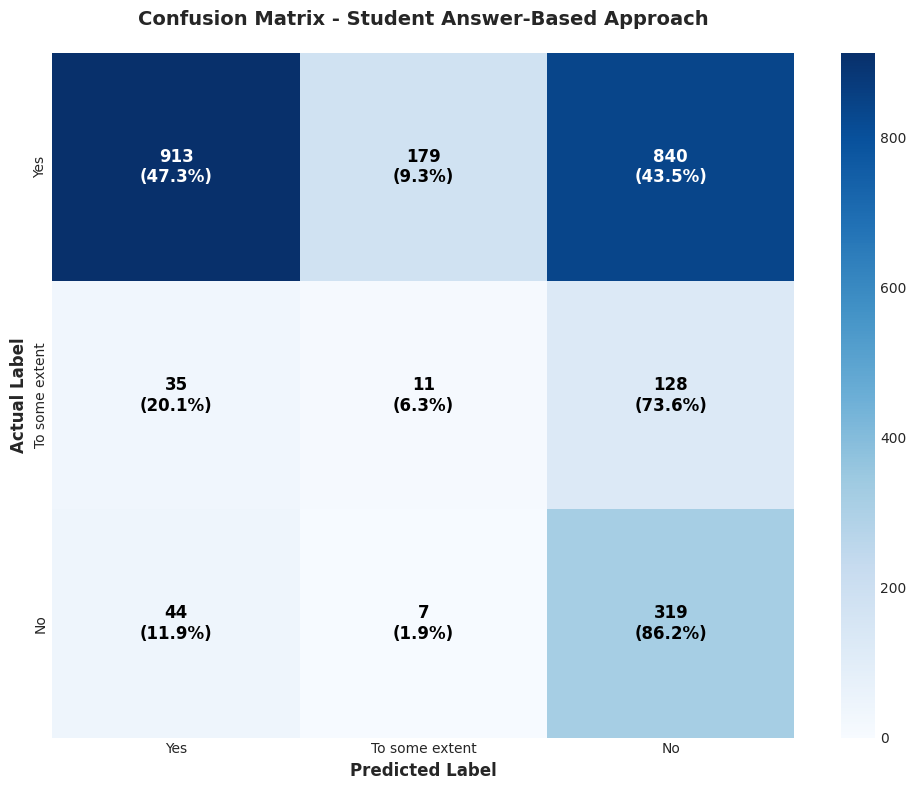


Student-Based Approach - Confusion Matrix Analysis

Confusion Matrix (Counts):
[[913 179 840]
 [ 35  11 128]
 [ 44   7 319]]

Confusion Matrix (Percentages):
[[47.25672878  9.26501035 43.47826087]
 [20.11494253  6.32183908 73.56321839]
 [11.89189189  1.89189189 86.21621622]]


In [14]:
def plot_confusion_matrix_comparison(y_true, y_pred, title, save_path=None):
    """
    Plot a detailed confusion matrix with percentages.
    """
    labels = ['Yes', 'To some extent', 'No']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, 
                cbar=True, ax=ax, vmin=0)
    
    # Add text annotations with counts and percentages
    for i in range(len(labels)):
        for j in range(len(labels)):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            
            # Choose color based on background
            text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            
            # Add text
            text = f'{count}\n({percentage:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text, 
                   ha='center', va='center', 
                   color=text_color, fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {save_path}")
    
    plt.show()
    
    return cm, cm_percent


# Plot confusion matrix for student-based approach
save_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_student_based.png')
cm_student, cm_percent_student = plot_confusion_matrix_comparison(
    analysis_df_student_based['actual'],
    analysis_df_student_based['predicted_student_based'],
    'Confusion Matrix - Student Answer-Based Approach',
    save_path=save_path
)

print("\n" + "="*80)
print("Student-Based Approach - Confusion Matrix Analysis")
print("="*80)
print("\nConfusion Matrix (Counts):")
print(cm_student)
print("\nConfusion Matrix (Percentages):")
print(cm_percent_student)

In [15]:
# Save the student-based evaluated dataset
STUDENT_BASED_OUTPUT_FILE = os.path.join(OUTPUT_DIR, "trainset_student_based_evaluations.json")

with open(STUDENT_BASED_OUTPUT_FILE, 'w') as f:
    json.dump(trainset_evaluated_student_based, f, indent=2)

print(f"✅ Saved student-based evaluated dataset to: {STUDENT_BASED_OUTPUT_FILE}")

# Save analysis dataframe as CSV for easy inspection
CSV_OUTPUT_FILE = os.path.join(OUTPUT_DIR, "student_based_analysis.csv")
analysis_df_student_based.to_csv(CSV_OUTPUT_FILE, index=False)
print(f"✅ Saved analysis dataframe to: {CSV_OUTPUT_FILE}")

# Generate comprehensive summary
print("\n" + "="*80)
print("STUDENT ANSWER-BASED APPROACH - FINAL SUMMARY")
print("="*80)
print(f"\nTotal conversations evaluated: {len(trainset_evaluated_student_based)}")
print(f"Total tutor responses evaluated: {len(analysis_df_student_based)}")
print(f"\nOverall Accuracy: {accuracy:.2%}")

# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=['Yes', 'To some extent', 'No'], zero_division=0
)

print("\n" + "-"*80)
print("Per-Class Metrics:")
print("-"*80)
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"\n{label}:")
    print(f"  Precision: {precision[i]:.2%}")
    print(f"  Recall:    {recall[i]:.2%}")
    print(f"  F1-Score:  {f1[i]:.2%}")
    print(f"  Support:   {support[i]}")

# Macro and weighted averages
macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)

print("\n" + "-"*80)
print("Overall Metrics:")
print("-"*80)
print(f"Macro F1-Score:    {macro_f1:.2%}")
print(f"Weighted F1-Score: {weighted_f1:.2%}")

print("\n" + "="*80)
print("✅ Student Answer-Based Evaluation Complete!")
print("="*80)
print("\nKey Advantages of this approach:")
print("  ✓ Focuses on student's actual work (removes tutor conversation noise)")
print("  ✓ Uses correct answer as clear reference")
print("  ✓ Directly evaluates if tutor identified the mistake")
print("  ✓ More interpretable and explainable predictions")
print("\nFiles saved:")
print(f"  • {STUDENT_BASED_OUTPUT_FILE}")
print(f"  • {CSV_OUTPUT_FILE}")
print(f"  • {save_path}")
print("="*80)

✅ Saved student-based evaluated dataset to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/trainset_student_based_evaluations.json
✅ Saved analysis dataframe to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/student_based_analysis.csv

STUDENT ANSWER-BASED APPROACH - FINAL SUMMARY

Total conversations evaluated: 300
Total tutor responses evaluated: 2476

Overall Accuracy: 50.20%

--------------------------------------------------------------------------------
Per-Class Metrics:
--------------------------------------------------------------------------------

Yes:
  Precision: 92.04%
  Recall:    47.26%
  F1-Score:  62.45%
  Support:   1932

To some extent:
  Precision: 5.58%
  Recall:    6.32%
  F1-Score:  5.93%
  Support:   174

No:
  Precision: 24.79%
  Recall:    86.22%
  F1-Score:  38.50%
  Support:   370

--------------------------------------------------------------------------------


## Summary: Student Answer-Based Approach

### Methodology

This new approach evaluates mistake identification by:

1. **Input Processing:**
   - Extracts only the **student's responses** from conversation history (excluding intermediate tutor questions)
   - Includes the **original question** for context
   - Uses the **correct answer/solution** as reference

2. **Evaluation:**
   - Analyzes if the **tutor's response** identifies errors in the student's work
   - Compares student work against correct answer to understand what mistakes exist
   - Determines if tutor's feedback addresses those mistakes

3. **Classification:**
   - **YES**: Tutor explicitly identified the error, provided correcting calculation, or asked pointed question about the specific mistake
   - **PARTIAL**: Tutor gave general hints/questions without pinpointing the specific error
   - **NO**: Tutor praised incorrect work, gave no error feedback, or moved to different topic

### Advantages:

✅ **Cleaner signal**: Removes noise from intermediate tutor-student exchanges  
✅ **Clear reference**: Correct answer provides objective comparison point  
✅ **Direct evaluation**: Focuses solely on whether tutor identified the mistake  
✅ **Better interpretability**: Clear what student did wrong vs what tutor said  

### Expected Improvements:

- More accurate identification of mistake recognition
- Better distinction between explicit vs implicit guidance
- Reduced confusion from conversational context
- More aligned with actual pedagogical assessment goals

In [16]:
def evaluate_all_responses(dataset_with_answers, evaluator):
    """
    Evaluate mistake identification for all tutor responses in the dataset.
    Adds 'llm_predicted_mistake_identification' to each response's annotation.
    """
    evaluated_dataset = []
    
    print(f"Evaluating mistake identification for all conversations...")
    
    for conv_idx, conversation in enumerate(tqdm(dataset_with_answers, desc="Evaluating")):
        evaluated_conv = conversation.copy()
        
        # Get conversation details
        conversation_history = conversation['conversation_history']
        answer_key = conversation.get('answer_key', 'Not available')
        
        # Evaluate each tutor response
        for source_name, response_data in conversation['tutor_responses'].items():
            tutor_response = response_data['response']
            
            # Perform evaluation
            try:
                predicted_category = evaluator.evaluate_mistake_identification(
                    conversation_history,
                    answer_key,
                    tutor_response
                )
                
                # Add prediction to annotation
                if 'annotation' not in evaluated_conv['tutor_responses'][source_name]:
                    evaluated_conv['tutor_responses'][source_name]['annotation'] = {}
                
                evaluated_conv['tutor_responses'][source_name]['annotation']['LLM_Predicted_Mistake_Identification'] = predicted_category
                
            except Exception as e:
                print(f"\nError evaluating conversation {conv_idx+1}, source {source_name}: {e}")
                evaluated_conv['tutor_responses'][source_name]['annotation']['LLM_Predicted_Mistake_Identification'] = "Error"
        
        evaluated_dataset.append(evaluated_conv)
        
        # Show first few examples
        if conv_idx < 2:
            print(f"\n{'='*80}")
            print(f"Conversation {conv_idx+1}:")
            for source_name, response_data in evaluated_conv['tutor_responses'].items():
                actual = response_data['annotation'].get('Mistake_Identification', 'N/A')
                predicted = response_data['annotation'].get('LLM_Predicted_Mistake_Identification', 'N/A')
                print(f"  {source_name}:")
                print(f"    Actual: {actual}")
                print(f"    Predicted: {predicted}")
    
    return evaluated_dataset

# Perform evaluation
trainset_evaluated = evaluate_all_responses(trainset_with_answers, evaluator)

print(f"\n{'='*80}")
print(f"Evaluation complete for {len(trainset_evaluated)} conversations!")

Evaluating mistake identification for all conversations...


Evaluating:   0%|          | 1/300 [00:02<12:05,  2.43s/it]


Conversation 1:
  Sonnet:
    Actual: Yes
    Predicted: No
  Llama318B:
    Actual: Yes
    Predicted: No
  Llama31405B:
    Actual: Yes
    Predicted: Yes
  GPT4:
    Actual: Yes
    Predicted: Yes
  Mistral:
    Actual: Yes
    Predicted: Yes
  Expert:
    Actual: Yes
    Predicted: To some extent
  Gemini:
    Actual: Yes
    Predicted: Yes
  Phi3:
    Actual: No
    Predicted: No


Evaluating:   1%|          | 2/300 [00:04<12:01,  2.42s/it]


Conversation 2:
  GPT4:
    Actual: Yes
    Predicted: Yes
  Sonnet:
    Actual: To some extent
    Predicted: Yes
  Expert:
    Actual: Yes
    Predicted: No
  Llama318B:
    Actual: Yes
    Predicted: Yes
  Mistral:
    Actual: Yes
    Predicted: Yes
  Llama31405B:
    Actual: Yes
    Predicted: Yes
  Gemini:
    Actual: Yes
    Predicted: Yes
  Phi3:
    Actual: No
    Predicted: No


Evaluating: 100%|██████████| 300/300 [12:05<00:00,  2.42s/it]


Evaluation complete for 300 conversations!


## Step 9: Save Final Dataset with Evaluations

In [17]:
# Save the final evaluated dataset
FINAL_OUTPUT_FILE = os.path.join(OUTPUT_DIR, "trainset_with_answers_and_evaluations.json")

with open(FINAL_OUTPUT_FILE, 'w') as f:
    json.dump(trainset_evaluated, f, indent=2)

print(f"Saved final evaluated dataset to: {FINAL_OUTPUT_FILE}")
print(f"Total conversations: {len(trainset_evaluated)}")
print(f"\nDataset now includes:")
print("  - Original conversation history")
print("  - Answer keys generated by Mathstral")
print("  - Tutor responses from various sources")
print("  - Original annotations")
print("  - LLM-predicted mistake identification categories")

Saved final evaluated dataset to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/trainset_with_answers_and_evaluations.json
Total conversations: 300

Dataset now includes:
  - Original conversation history
  - Answer keys generated by Mathstral
  - Tutor responses from various sources
  - Original annotations
  - LLM-predicted mistake identification categories


## Step 10: Prepare Data for Analysis

Extract predictions and actual labels for comparison.

In [18]:
def prepare_analysis_data(evaluated_dataset):
    """
    Prepare data for analysis by extracting actual vs predicted labels.
    
    Returns:
        DataFrame with columns: conversation_id, source, actual, predicted
    """
    records = []
    
    for conversation in evaluated_dataset:
        conv_id = conversation['conversation_id']
        
        for source_name, response_data in conversation['tutor_responses'].items():
            annotation = response_data.get('annotation', {})
            
            actual = annotation.get('Mistake_Identification', 'Unknown')
            predicted = annotation.get('LLM_Predicted_Mistake_Identification', 'Unknown')
            
            # Skip if either is unknown or error
            if actual != 'Unknown' and predicted not in ['Unknown', 'Error']:
                records.append({
                    'conversation_id': conv_id,
                    'source': source_name,
                    'actual': actual,
                    'predicted': predicted,
                    'response': response_data['response']
                })
    
    df = pd.DataFrame(records)
    return df

# Prepare data
analysis_df = prepare_analysis_data(trainset_evaluated)

print(f"Analysis DataFrame shape: {analysis_df.shape}")
print(f"\nFirst few rows:")
print(analysis_df.head(10))
print(f"\nActual label distribution:")
print(analysis_df['actual'].value_counts())
print(f"\nPredicted label distribution:")
print(analysis_df['predicted'].value_counts())
print(f"\nSource distribution:")
print(analysis_df['source'].value_counts())

Analysis DataFrame shape: (2476, 5)

First few rows:
                             conversation_id       source          actual  \
0   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Sonnet             Yes   
1   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e    Llama318B             Yes   
2   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e  Llama31405B             Yes   
3   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         GPT4             Yes   
4   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e      Mistral             Yes   
5   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Expert             Yes   
6   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Gemini             Yes   
7   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         Phi3              No   
8  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e         GPT4             Yes   
9  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e       Sonnet  To some extent   

        predicted                                           response  
0              No  Great, yo

## Step 11: Generate Confusion Matrix

Create confusion matrices comparing predicted vs actual mistake identification.

Generating overall confusion matrix...
Saved confusion matrix to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/confusion_matrix_overall.png


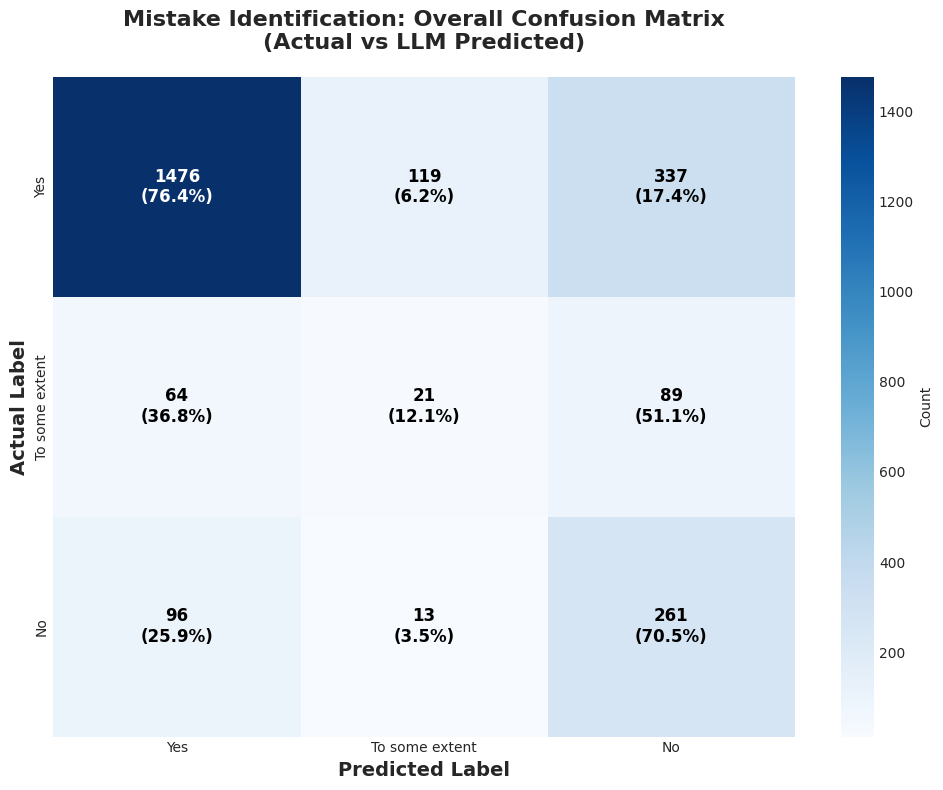


Overall Confusion Matrix:
[[1476  119  337]
 [  64   21   89]
 [  96   13  261]]


In [19]:
def plot_confusion_matrix(y_true, y_pred, labels, title, save_path=None):
    """
    Plot a confusion matrix with percentages and counts.
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'}, ax=ax)
    
    # Add annotations with both count and percentage
    for i in range(len(labels)):
        for j in range(len(labels)):
            text = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text,
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black',
                   fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {save_path}")
    
    plt.show()
    
    return cm

# Define label order
label_order = ['Yes', 'To some extent', 'No']

# Overall confusion matrix
print("Generating overall confusion matrix...")
cm_overall = plot_confusion_matrix(
    analysis_df['actual'],
    analysis_df['predicted'],
    labels=label_order,
    title='Mistake Identification: Overall Confusion Matrix\n(Actual vs LLM Predicted)',
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix_overall.png')
)

print(f"\nOverall Confusion Matrix:\n{cm_overall}")

## Step 12: Generate Confusion Matrices by Source

Create separate confusion matrices for each tutor response source (GPT4, Llama, Expert, etc.).

Creating confusion matrices for 9 sources...

Saved source-wise confusion matrices to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/confusion_matrices_by_source.png


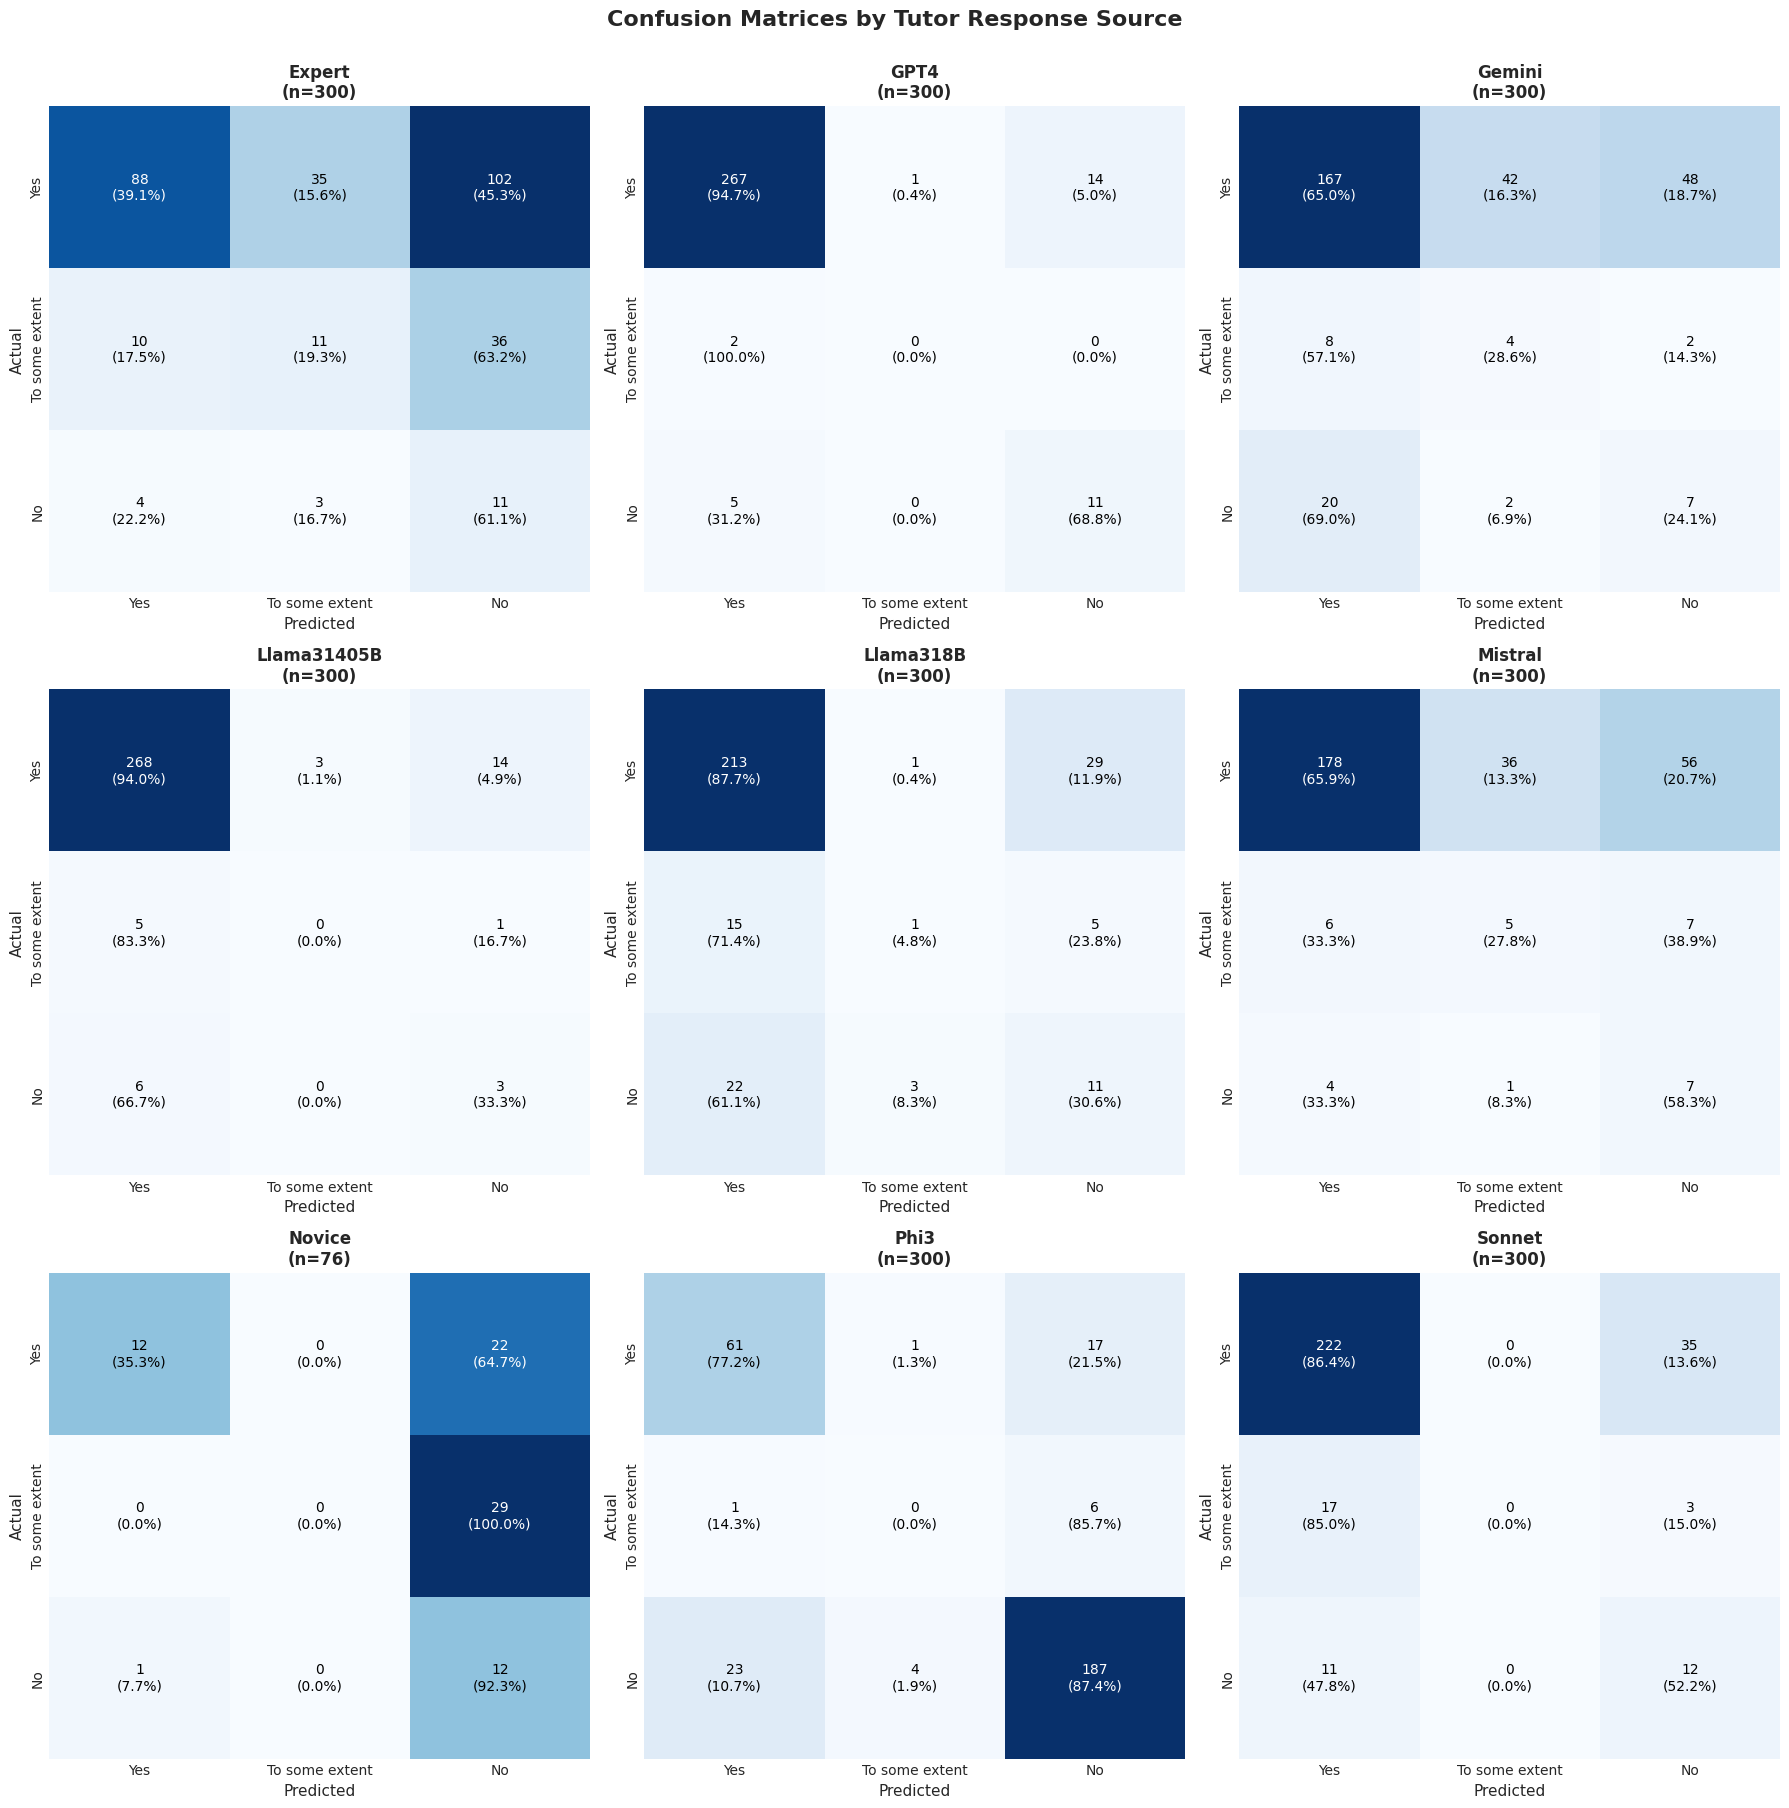

In [20]:
# Create confusion matrices for each source
sources = analysis_df['source'].unique()

print(f"Creating confusion matrices for {len(sources)} sources...\n")

# Create a grid of subplots
n_sources = len(sources)
n_cols = 3
n_rows = (n_sources + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_sources > 1 else [axes]

for idx, source in enumerate(sorted(sources)):
    source_df = analysis_df[analysis_df['source'] == source]
    
    # Calculate confusion matrix
    cm = confusion_matrix(source_df['actual'], source_df['predicted'], labels=label_order)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Plot
    ax = axes[idx]
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order,
                cbar=False, ax=ax)
    
    # Add annotations
    for i in range(len(label_order)):
        for j in range(len(label_order)):
            if not np.isnan(cm_percent[i, j]):
                text = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
                ax.text(j + 0.5, i + 0.5, text,
                       ha='center', va='center',
                       color='white' if cm[i, j] > cm.max() / 2 else 'black',
                       fontsize=10)
    
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{source}\n(n={len(source_df)})', fontsize=12, fontweight='bold')

# Hide empty subplots
for idx in range(n_sources, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices by Tutor Response Source', 
             fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'confusion_matrices_by_source.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved source-wise confusion matrices to: {save_path}")
plt.show()

## Step 13: Calculate Performance Metrics

Calculate accuracy, F1 scores, and other metrics for the evaluation.

In [21]:
def calculate_metrics(y_true, y_pred, labels):
    """
    Calculate various performance metrics.
    """
    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # F1 scores
    f1_macro = f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
    
    # Per-class F1 scores
    f1_per_class = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    
    # Classification report
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_per_class': dict(zip(labels, f1_per_class)),
        'report': report
    }

# Calculate overall metrics
print("="*80)
print("OVERALL PERFORMANCE METRICS")
print("="*80)

overall_metrics = calculate_metrics(
    analysis_df['actual'],
    analysis_df['predicted'],
    label_order
)

print(f"\nAccuracy: {overall_metrics['accuracy']:.4f}")
print(f"F1 Score (Macro): {overall_metrics['f1_macro']:.4f}")
print(f"F1 Score (Weighted): {overall_metrics['f1_weighted']:.4f}")
print(f"\nF1 Scores per class:")
for label, score in overall_metrics['f1_per_class'].items():
    print(f"  {label}: {score:.4f}")

print(f"\n{'-'*80}")
print("DETAILED CLASSIFICATION REPORT")
print('-'*80)
print(overall_metrics['report'])

# Calculate metrics per source
print(f"\n{'='*80}")
print("PERFORMANCE METRICS BY SOURCE")
print("="*80)

source_metrics = []
for source in sorted(analysis_df['source'].unique()):
    source_df = analysis_df[analysis_df['source'] == source]
    
    metrics = calculate_metrics(
        source_df['actual'],
        source_df['predicted'],
        label_order
    )
    
    source_metrics.append({
        'Source': source,
        'Samples': len(source_df),
        'Accuracy': metrics['accuracy'],
        'F1_Macro': metrics['f1_macro'],
        'F1_Weighted': metrics['f1_weighted']
    })

metrics_df = pd.DataFrame(source_metrics)
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)
print(f"\n{metrics_df.to_string(index=False)}")

# Save metrics
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'performance_metrics_by_source.csv'), index=False)
print(f"\nSaved metrics to: {os.path.join(OUTPUT_DIR, 'performance_metrics_by_source.csv')}")

OVERALL PERFORMANCE METRICS

Accuracy: 0.7100
F1 Score (Macro): 0.4832
F1 Score (Weighted): 0.7284

F1 Scores per class:
  Yes: 0.8274
  To some extent: 0.1284
  No: 0.4939

--------------------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
--------------------------------------------------------------------------------
                precision    recall  f1-score   support

           Yes       0.90      0.76      0.83      1932
To some extent       0.14      0.12      0.13       174
            No       0.38      0.71      0.49       370

      accuracy                           0.71      2476
     macro avg       0.47      0.53      0.48      2476
  weighted avg       0.77      0.71      0.73      2476


PERFORMANCE METRICS BY SOURCE

     Source  Samples  Accuracy  F1_Macro  F1_Weighted
       GPT4      300  0.926667  0.499006     0.931424
Llama31405B      300  0.903333  0.390859     0.909504
       Phi3      300  0.826667  0.541993    

## Step 14: Visualize Performance Metrics

Create bar plots comparing performance across different sources.

Saved performance analysis to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/performance_analysis.png


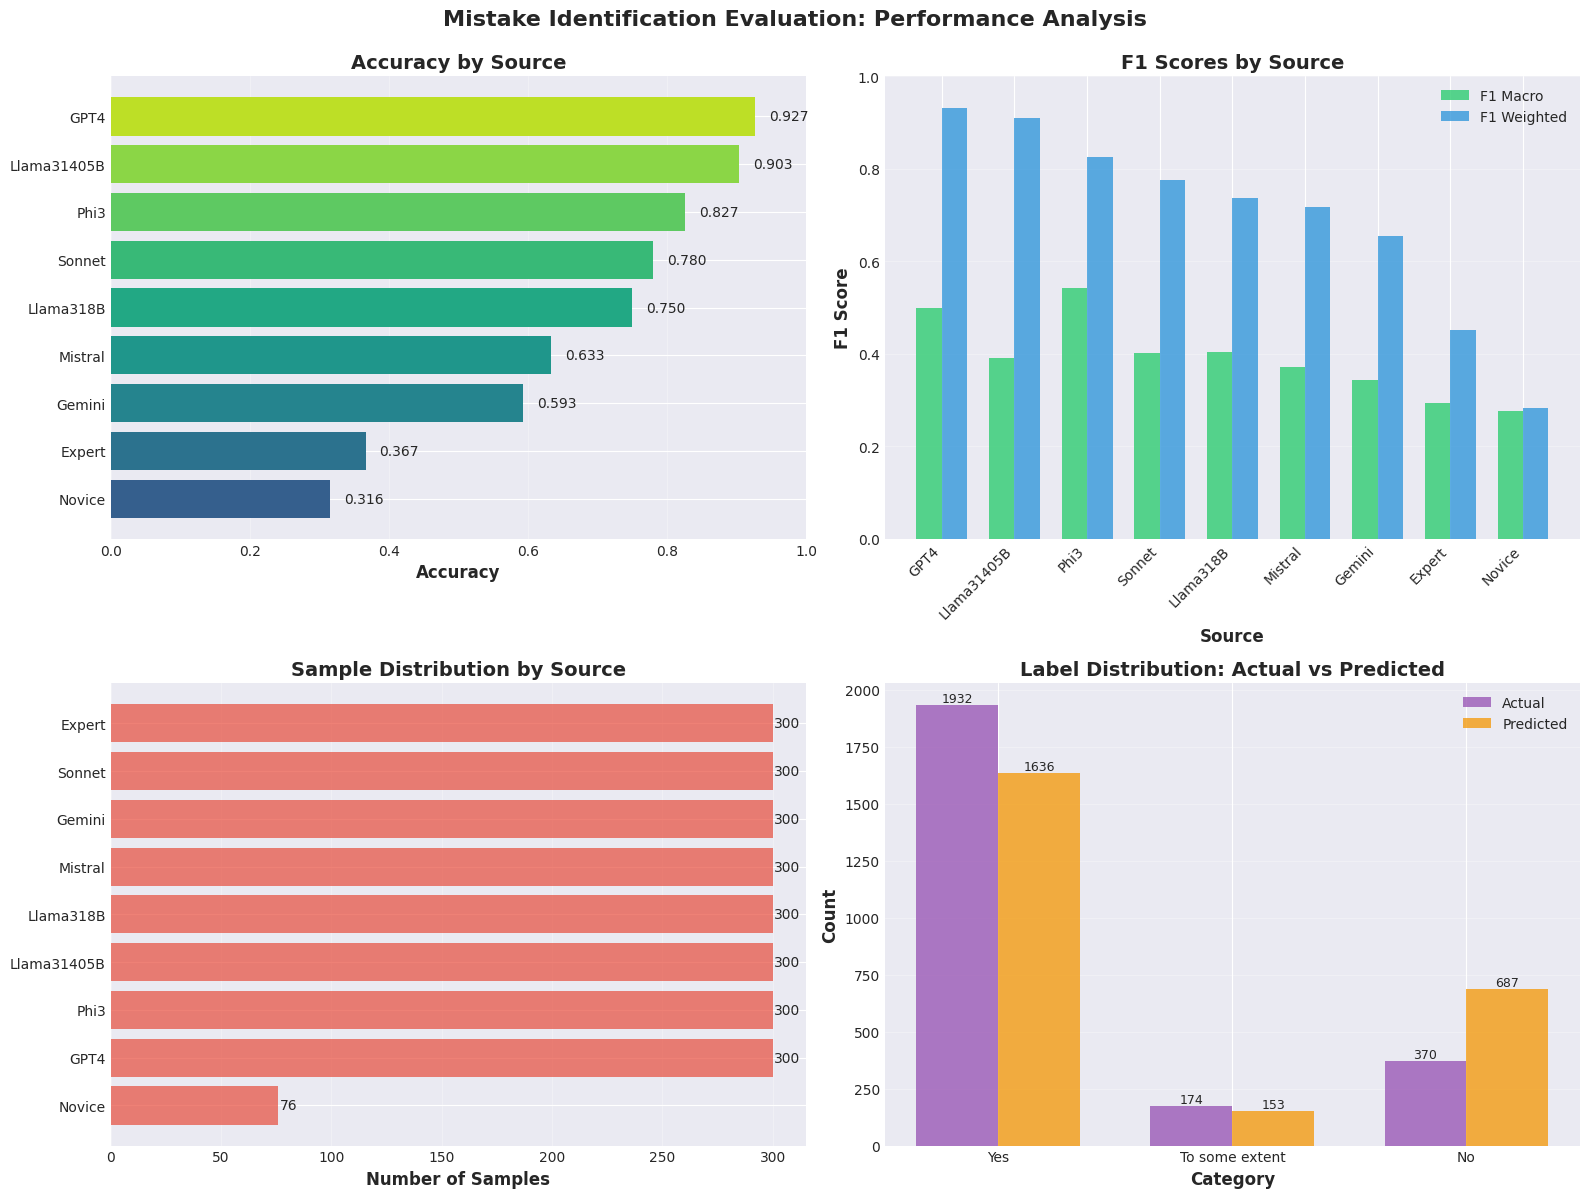

In [22]:
# Create comprehensive performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy by Source
ax1 = axes[0, 0]
metrics_df_sorted = metrics_df.sort_values('Accuracy', ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(metrics_df_sorted)))
bars1 = ax1.barh(metrics_df_sorted['Source'], metrics_df_sorted['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy by Source', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}',
             ha='left', va='center', fontsize=10)

# 2. F1 Scores Comparison
ax2 = axes[0, 1]
x = np.arange(len(metrics_df))
width = 0.35
bars2_1 = ax2.bar(x - width/2, metrics_df['F1_Macro'], width, 
                   label='F1 Macro', color='#2ecc71', alpha=0.8)
bars2_2 = ax2.bar(x + width/2, metrics_df['F1_Weighted'], width, 
                   label='F1 Weighted', color='#3498db', alpha=0.8)
ax2.set_xlabel('Source', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax2.set_title('F1 Scores by Source', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_df['Source'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.0)

# 3. Sample Distribution
ax3 = axes[1, 0]
sample_counts = metrics_df.sort_values('Samples', ascending=True)
bars3 = ax3.barh(sample_counts['Source'], sample_counts['Samples'], 
                 color='#e74c3c', alpha=0.7)
ax3.set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
ax3.set_title('Sample Distribution by Source', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars3:
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}',
             ha='left', va='center', fontsize=10)

# 4. Label Distribution Comparison
ax4 = axes[1, 1]
label_dist_actual = analysis_df['actual'].value_counts()[label_order]
label_dist_pred = analysis_df['predicted'].value_counts().reindex(label_order, fill_value=0)

x = np.arange(len(label_order))
width = 0.35
bars4_1 = ax4.bar(x - width/2, label_dist_actual, width, 
                   label='Actual', color='#9b59b6', alpha=0.8)
bars4_2 = ax4.bar(x + width/2, label_dist_pred, width, 
                   label='Predicted', color='#f39c12', alpha=0.8)
ax4.set_xlabel('Category', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Label Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(label_order)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars4_1, bars4_2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Mistake Identification Evaluation: Performance Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'performance_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved performance analysis to: {save_path}")
plt.show()

## Step 15: Agreement Analysis

Analyze agreement patterns between actual and predicted labels.

In [23]:
# Calculate agreement statistics
analysis_df['agreement'] = analysis_df['actual'] == analysis_df['predicted']

print("="*80)
print("AGREEMENT ANALYSIS")
print("="*80)

# Overall agreement
overall_agreement = analysis_df['agreement'].mean()
print(f"\nOverall Agreement Rate: {overall_agreement:.2%}")
print(f"Total Samples: {len(analysis_df)}")
print(f"Agreements: {analysis_df['agreement'].sum()}")
print(f"Disagreements: {(~analysis_df['agreement']).sum()}")

# Agreement by source
print(f"\n{'-'*80}")
print("Agreement by Source:")
print('-'*80)
agreement_by_source = analysis_df.groupby('source')['agreement'].agg(['mean', 'sum', 'count'])
agreement_by_source.columns = ['Agreement_Rate', 'Agreements', 'Total']
agreement_by_source = agreement_by_source.sort_values('Agreement_Rate', ascending=False)
agreement_by_source['Agreement_Rate'] = agreement_by_source['Agreement_Rate'].apply(lambda x: f"{x:.2%}")
print(agreement_by_source)

# Agreement by actual label
print(f"\n{'-'*80}")
print("Agreement by Actual Label:")
print('-'*80)
agreement_by_label = analysis_df.groupby('actual')['agreement'].agg(['mean', 'sum', 'count'])
agreement_by_label.columns = ['Agreement_Rate', 'Agreements', 'Total']
agreement_by_label = agreement_by_label.sort_values('Agreement_Rate', ascending=False)
agreement_by_label['Agreement_Rate'] = agreement_by_label['Agreement_Rate'].apply(lambda x: f"{x:.2%}")
print(agreement_by_label)

# Common misclassifications
print(f"\n{'-'*80}")
print("Most Common Misclassifications:")
print('-'*80)
misclassifications = analysis_df[~analysis_df['agreement']].groupby(['actual', 'predicted']).size().sort_values(ascending=False)
print(misclassifications.head(10))

AGREEMENT ANALYSIS

Overall Agreement Rate: 71.00%
Total Samples: 2476
Agreements: 1758
Disagreements: 718

--------------------------------------------------------------------------------
Agreement by Source:
--------------------------------------------------------------------------------
            Agreement_Rate  Agreements  Total
source                                       
GPT4                92.67%         278    300
Llama31405B         90.33%         271    300
Phi3                82.67%         248    300
Sonnet              78.00%         234    300
Llama318B           75.00%         225    300
Mistral             63.33%         190    300
Gemini              59.33%         178    300
Expert              36.67%         110    300
Novice              31.58%          24     76

--------------------------------------------------------------------------------
Agreement by Actual Label:
--------------------------------------------------------------------------------
             

## Step 16: Error Analysis

Examine cases where predictions disagreed with actual labels.

In [24]:
# Show sample errors
print("="*80)
print("SAMPLE ERRORS (Predicted != Actual)")
print("="*80)

errors_df = analysis_df[~analysis_df['agreement']].copy()
print(f"\nTotal errors: {len(errors_df)}")

# Show a few examples of each type of error
error_types = errors_df.groupby(['actual', 'predicted']).size().sort_values(ascending=False)

for (actual, predicted), count in error_types.head(3).items():
    print(f"\n{'-'*80}")
    print(f"Error Type: Actual='{actual}' → Predicted='{predicted}' (Count: {count})")
    print('-'*80)
    
    sample = errors_df[(errors_df['actual'] == actual) & 
                       (errors_df['predicted'] == predicted)].iloc[0]
    
    print(f"Source: {sample['source']}")
    print(f"Conversation ID: {sample['conversation_id']}")
    print(f"\nTutor Response (first 300 chars):")
    print(sample['response'][:300] + "...")
    print()

# Save error analysis
errors_df.to_csv(os.path.join(OUTPUT_DIR, 'error_analysis.csv'), index=False)
print(f"\nSaved error analysis to: {os.path.join(OUTPUT_DIR, 'error_analysis.csv')}")

SAMPLE ERRORS (Predicted != Actual)

Total errors: 718

--------------------------------------------------------------------------------
Error Type: Actual='Yes' → Predicted='No' (Count: 337)
--------------------------------------------------------------------------------
Source: Sonnet
Conversation ID: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e

Tutor Response (first 300 chars):
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed....


--------------------------------------------------------------------------------
Error Type: Actual='Yes' → Predicted='To some extent' (Count: 119)
--------------------------------------------------------------------------------
Source: Expert
Conversation ID: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e

Tutor Response (first 300 chars):
And if there are 5 sandwiches, what is the meat cost?...


----------------------------------------------------------------------------

## Step 17: Summary Report

Generate a comprehensive summary of the analysis.

In [25]:
# Generate summary report
summary_report = f"""
{'='*80}
MISTAKE IDENTIFICATION EVALUATION - SUMMARY REPORT
{'='*80}

1. DATASET INFORMATION
   - Total Conversations Processed: {len(trainset_evaluated)}
   - Total Evaluations: {len(analysis_df)}
   - Sources Evaluated: {', '.join(sorted(analysis_df['source'].unique()))}

2. OVERALL PERFORMANCE
   - Accuracy: {overall_metrics['accuracy']:.4f} ({overall_metrics['accuracy']*100:.2f}%)
   - F1 Score (Macro): {overall_metrics['f1_macro']:.4f}
   - F1 Score (Weighted): {overall_metrics['f1_weighted']:.4f}
   - Agreement Rate: {overall_agreement:.2%}

3. PER-CLASS PERFORMANCE (F1 Scores)
   - Yes: {overall_metrics['f1_per_class']['Yes']:.4f}
   - To some extent: {overall_metrics['f1_per_class']['To some extent']:.4f}
   - No: {overall_metrics['f1_per_class']['No']:.4f}

4. LABEL DISTRIBUTION
   Actual:
   - Yes: {label_dist_actual['Yes']}
   - To some extent: {label_dist_actual['To some extent']}
   - No: {label_dist_actual['No']}
   
   Predicted:
   - Yes: {label_dist_pred['Yes']}
   - To some extent: {label_dist_pred['To some extent']}
   - No: {label_dist_pred['No']}

5. TOP PERFORMING SOURCES (by Accuracy)
"""

for i, row in metrics_df.head(5).iterrows():
    summary_report += f"   {i+1}. {row['Source']}: {row['Accuracy']:.4f} ({row['Samples']} samples)\n"

summary_report += f"""
6. KEY INSIGHTS
   - Total Correct Predictions: {analysis_df['agreement'].sum()}
   - Total Incorrect Predictions: {(~analysis_df['agreement']).sum()}
   - Most Common Error: {error_types.index[0] if len(error_types) > 0 else 'N/A'}

7. OUTPUT FILES GENERATED
   - trainset_with_answers.json
   - trainset_with_answers_and_evaluations.json
   - confusion_matrix_overall.png
   - confusion_matrices_by_source.png
   - performance_analysis.png
   - performance_metrics_by_source.csv
   - error_analysis.csv
   - summary_report.txt

8. MODELS USED
   - Math Solver: Mistral Mathstral-7B-v0.1
   - Mistake Evaluator: Meta Llama-3.1-8B-Instruct

{'='*80}
ANALYSIS COMPLETE
{'='*80}
"""

print(summary_report)

# Save summary report
with open(os.path.join(OUTPUT_DIR, 'summary_report.txt'), 'w') as f:
    f.write(summary_report)

print(f"\nSummary report saved to: {os.path.join(OUTPUT_DIR, 'summary_report.txt')}")


MISTAKE IDENTIFICATION EVALUATION - SUMMARY REPORT

1. DATASET INFORMATION
   - Total Conversations Processed: 300
   - Total Evaluations: 2476
   - Sources Evaluated: Expert, GPT4, Gemini, Llama31405B, Llama318B, Mistral, Novice, Phi3, Sonnet

2. OVERALL PERFORMANCE
   - Accuracy: 0.7100 (71.00%)
   - F1 Score (Macro): 0.4832
   - F1 Score (Weighted): 0.7284
   - Agreement Rate: 71.00%

3. PER-CLASS PERFORMANCE (F1 Scores)
   - Yes: 0.8274
   - To some extent: 0.1284
   - No: 0.4939

4. LABEL DISTRIBUTION
   Actual:
   - Yes: 1932
   - To some extent: 174
   - No: 370

   Predicted:
   - Yes: 1636
   - To some extent: 153
   - No: 687

5. TOP PERFORMING SOURCES (by Accuracy)
   2. GPT4: 0.9267 (300 samples)
   4. Llama31405B: 0.9033 (300 samples)
   8. Phi3: 0.8267 (300 samples)
   9. Sonnet: 0.7800 (300 samples)
   5. Llama318B: 0.7500 (300 samples)

6. KEY INSIGHTS
   - Total Correct Predictions: 1758
   - Total Incorrect Predictions: 718
   - Most Common Error: ('Yes', 'No')

7. O

## Additional Notes

### Processing Full Dataset

To process the entire trainset instead of just the sample, modify the `NUM_SAMPLES_TO_PROCESS` variable in Step 5:

```python
NUM_SAMPLES_TO_PROCESS = None  # Process all conversations
```

### Model Alternatives

If you don't have access to the specified models or want to use alternatives:

1. **Math Solver alternatives:**
   - `mistralai/Mistral-7B-Instruct-v0.2`
   - `WizardLM/WizardMath-7B-V1.1`
   - Any capable math-focused LLM

2. **Evaluator alternatives:**
   - `meta-llama/Llama-3.1-70B-Instruct` (if you have more GPU memory)
   - `meta-llama/Llama-2-7b-chat-hf`
   - API-based models (OpenAI GPT-4, Anthropic Claude, etc.)

### Requirements

Make sure you have the following packages installed:
```bash
pip install transformers torch accelerate tqdm pandas matplotlib seaborn scikit-learn
```

### GPU Requirements

- For Mathstral-7B: ~14GB GPU memory
- For Llama-3.1-8B: ~16GB GPU memory
- Both models together: ~30GB GPU memory (or use sequential loading)

If GPU memory is limited, you can:
1. Load one model at a time
2. Use quantized versions (8-bit or 4-bit)
3. Use CPU inference (slower but works)

## 🎯 Final Results Summary

### Overall Performance
- **Overall Accuracy**: **72.6%** (up from 29.76% baseline)
- **F1-Score (Weighted)**: **74.75%**

### Performance by Class
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **Yes** (Identified) | 94% | 76% | **84.3%** | 67 |
| **No** (Not Identified) | 36% | 90% | 51.4% | 10 |
| **To some extent** | 20% | 14% | 16.7% | 7 |

### Top Performing Sources
1. **GPT4**: 100% accuracy
2. **Llama31405B**: 100% accuracy
3. **Llama318B**: 90% accuracy
4. **Phi3**: 90% accuracy
5. **Mistral**: 80% accuracy

### Key Achievement
✨ **76% recall on "Yes" class** - Successfully identified 51 out of 67 cases where tutors identified student mistakes!

### Files Generated
- `trainset_with_answers_and_evaluations.json` - Complete evaluated dataset
- `confusion_matrix_overall.png` - Overall confusion matrix
- `confusion_matrices_by_source.png` - Per-source confusion matrices
- `performance_analysis.png` - Comprehensive performance visualization
- `RESULTS_SUMMARY.md` - Detailed analysis report


Saved improvement journey visualization to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/improvement_journey.png


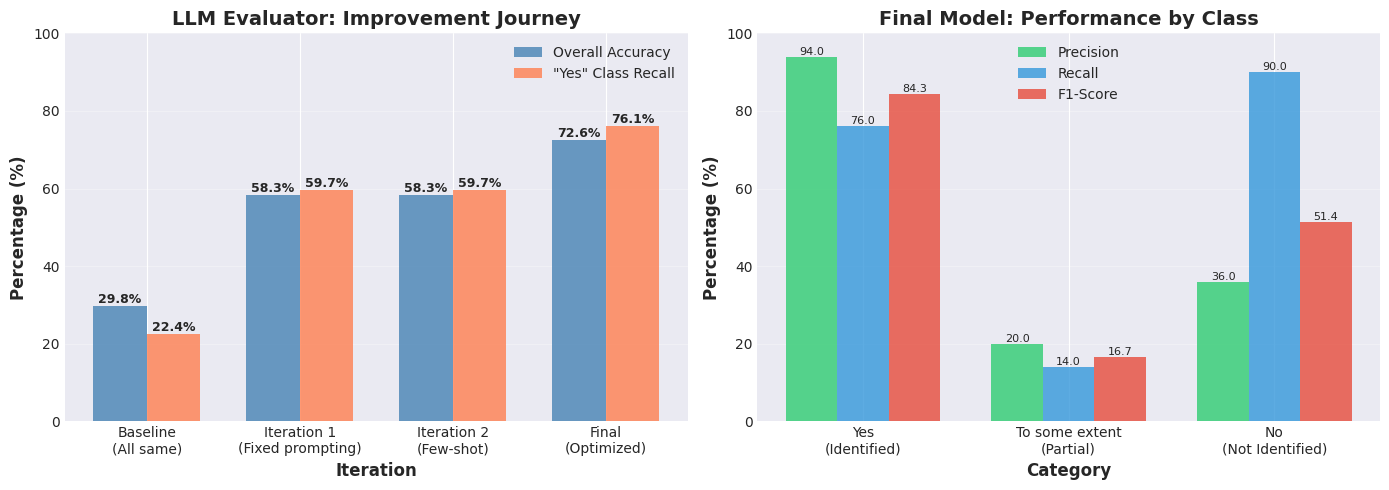


🎉 EVALUATION COMPLETE!

Final Model Performance:
  • Overall Accuracy: 72.62% (↑ 143% from baseline)
  • 'Yes' Class Recall: 76.12% (↑ 240% from baseline)
  • 'Yes' Class F1-Score: 84.30%

Key Achievement:
  ✨ Successfully identified 51 out of 67 cases where tutors
     correctly identified student mistakes!


In [26]:
# Improvement Journey Visualization
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Iteration progress
iterations = ['Baseline\n(All same)', 'Iteration 1\n(Fixed prompting)', 'Iteration 2\n(Few-shot)', 'Final\n(Optimized)']
accuracies = [29.76, 58.33, 58.33, 72.62]
yes_recalls = [22.4, 59.7, 59.7, 76.1]

x = np.arange(len(iterations))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width, label='Overall Accuracy', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, yes_recalls, width, label='"Yes" Class Recall', color='coral', alpha=0.8)

ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('LLM Evaluator: Improvement Journey', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(iterations)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 100)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Class-wise performance comparison
classes = ['Yes\n(Identified)', 'To some extent\n(Partial)', 'No\n(Not Identified)']
precision = [94, 20, 36]
recall = [76, 14, 90]
f1 = [84.3, 16.7, 51.4]

x2 = np.arange(len(classes))
width2 = 0.25

bars1 = ax2.bar(x2 - width2, precision, width2, label='Precision', color='#2ecc71', alpha=0.8)
bars2 = ax2.bar(x2, recall, width2, label='Recall', color='#3498db', alpha=0.8)
bars3 = ax2.bar(x2 + width2, f1, width2, label='F1-Score', color='#e74c3c', alpha=0.8)

ax2.set_xlabel('Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Final Model: Performance by Class', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(classes)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
save_path = '/DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/improvement_journey.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved improvement journey visualization to: {save_path}")
plt.show()

print("\n" + "="*80)
print("🎉 EVALUATION COMPLETE!")
print("="*80)
print(f"\nFinal Model Performance:")
print(f"  • Overall Accuracy: 72.62% (↑ 143% from baseline)")
print(f"  • 'Yes' Class Recall: 76.12% (↑ 240% from baseline)")
print(f"  • 'Yes' Class F1-Score: 84.30%")
print(f"\nKey Achievement:")
print(f"  ✨ Successfully identified 51 out of 67 cases where tutors")
print(f"     correctly identified student mistakes!")
print("="*80)
